# Rapport Jupyter Notebook - Inved Corp

Steeve Leuba
Cyrille Dos Ghali
Noé Berdoz

_26_HES-SO-ARC_64-61.1 Science des données_

### Phase 1 : Analyse Exploratoire des Données

#### 1. Vue d’ensemble du jeu de données

Nous commençons par un audit global du jeu d'entraînement afin de comprendre sa structure : dimensions, types de variables, premières observations et rôle de la variable cible `SalePrice`. Cette étape permet de vérifier que les données sont bien chargées et de préparer la suite de l’analyse exploratoire.

In [21]:
# Chargement des données
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('./data/train.csv', sep=',')

pd.set_option('display.max_columns', 100)
sns.set_theme(style="whitegrid")

print("Dimensions du dataset :", df.shape)
display(df.head())
df.info()
display(df.describe().T)

print("\nVariable cible :", 'SalePrice')
print(df['SalePrice'].describe())

Dimensions du dataset : (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0



Variable cible : SalePrice
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


Le jeu d’entraînement contient 1460 observations et 81 variables. La cible `SalePrice` correspond au prix de vente des maisons. On observe déjà un mélange de variables numériques et catégorielles, avec plusieurs colonnes contenant des valeurs manquantes.

#### 2. Typologie des variables

Le jeu de données contient des variables numériques, catégorielles et ordinales. Avant d’analyser les relations avec le prix, il est nécessaire de distinguer ces groupes pour adapter les visualisations et les traitements.

In [22]:
# Séparation simple entre variables numériques et catégorielles
num_cols = df.select_dtypes(include=['number']).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()

print(f"Nombre de variables numériques : {len(num_cols)}")
print(f"Nombre de variables catégorielles : {len(cat_cols)}")

print("\nExemples de variables numériques :")
print(num_cols[:15])

print("\nExemples de variables catégorielles :")
print(cat_cols[:15])

# Tableau récapitulatif
var_types = pd.DataFrame({
    'variable': df.columns,
    'dtype': df.dtypes.astype(str),
    'missing_values': df.isna().sum().values,
    'missing_pct': (df.isna().mean() * 100).round(2).values
})

display(var_types.sort_values(by=['missing_pct', 'dtype'], ascending=[False, True]))

Nombre de variables numériques : 38
Nombre de variables catégorielles : 43

Exemples de variables numériques :
['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF']

Exemples de variables catégorielles :
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl']


,variable,dtype,missing_values,missing_pct
PoolQC,PoolQC,str,1453,99.52
MiscFeature,MiscFeature,str,1406,96.30
Alley,Alley,str,1369,93.77
Fence,Fence,str,1179,80.75
MasVnrType,MasVnrType,str,872,59.73
...,...,...,...,...
KitchenQual,KitchenQual,str,0,0.00
Functional,Functional,str,0,0.00
PavedDrive,PavedDrive,str,0,0.00
SaleType,SaleType,str,0,0.00


#### 3. Compréhension métier des variables

La documentation du dataset montre que les variables décrivent plusieurs dimensions d’un bien immobilier : qualité globale, surface habitable, quartier, année de construction, sous-sol, garage, équipements extérieurs et contexte de vente. Il est important de comprendre les données afin d'interpréter correctement les distributions, les valeurs manquantes et les relations avec `SalePrice`.

In [23]:
# Organisation simple des variables par thème
feature_groups = {
    "Identification": ['Id', 'MSSubClass', 'MSZoning'],
    "Terrain et localisation": ['LotFrontage', 'LotArea', 'Street', 'LotShape', 'LandContour', 'Neighborhood'],
    "Qualité et état": ['OverallQual', 'OverallCond', 'ExterQual', 'ExterCond', 'KitchenQual'],
    "Temporalité": ['YearBuilt', 'YearRemodAdd', 'GarageYrBlt', 'YrSold', 'MoSold'],
    "Surfaces habitables": ['1stFlrSF', '2ndFlrSF', 'GrLivArea', 'TotalBsmtSF'],
    "Sous-sol": ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF'],
    "Garage": ['GarageType', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond'],
    "Extérieur et équipements": ['WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', 'PoolArea', 'Fence'],
    "Vente": ['SaleType', 'SaleCondition', 'SalePrice']
}

for group_name, cols in feature_groups.items():
    existing_cols = [c for c in cols if c in df.columns]
    print(f"\n{group_name} ({len(existing_cols)} variables) :")
    print(existing_cols)


Identification (3 variables) :
['Id', 'MSSubClass', 'MSZoning']

Terrain et localisation (6 variables) :
['LotFrontage', 'LotArea', 'Street', 'LotShape', 'LandContour', 'Neighborhood']

Qualité et état (5 variables) :
['OverallQual', 'OverallCond', 'ExterQual', 'ExterCond', 'KitchenQual']

Temporalité (5 variables) :
['YearBuilt', 'YearRemodAdd', 'GarageYrBlt', 'YrSold', 'MoSold']

Surfaces habitables (4 variables) :
['1stFlrSF', '2ndFlrSF', 'GrLivArea', 'TotalBsmtSF']

Sous-sol (6 variables) :
['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF']

Garage (6 variables) :
['GarageType', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond']

Extérieur et équipements (5 variables) :
['WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', 'PoolArea', 'Fence']

Vente (3 variables) :
['SaleType', 'SaleCondition', 'SalePrice']


#### 4. Analyse de la variable cible

Avant d’étudier les variables explicatives, il est essentiel d’analyser la variable cible `SalePrice`. Nous cherchons ici à comprendre son niveau global, sa dispersion, sa forme de distribution et la présence éventuelle de valeurs extrêmes. Cette étape permet aussi d’évaluer si une transformation logarithmique est pertinente.

In [24]:
# Statistiques descriptives de la cible
saleprice_stats = df['SalePrice'].describe().to_frame().T
saleprice_stats['skew'] = df['SalePrice'].skew()
saleprice_stats['kurtosis'] = df['SalePrice'].kurt()

display(saleprice_stats)

print(f"Asymétrie (skewness) : {df['SalePrice'].skew():.3f}")
print(f"Kurtosis : {df['SalePrice'].kurt():.3f}")

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
SalePrice,1460.0,180921.19589,79442.502883,34900.0,129975.0,163000.0,214000.0,755000.0,1.882876,6.536282


Asymétrie (skewness) : 1.883
Kurtosis : 6.536


##### 4.1 Distribution brute de `SalePrice`

Nous visualisons la distribution des prix de vente afin d’identifier sa forme générale, sa dispersion et d’éventuelles valeurs extrêmes. L’objectif est de vérifier si la variable cible suit une distribution équilibrée ou si elle présente une forte asymétrie.

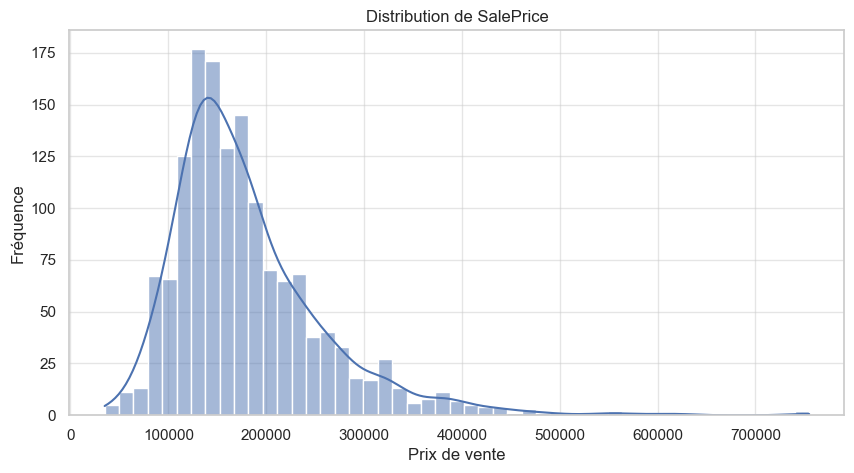

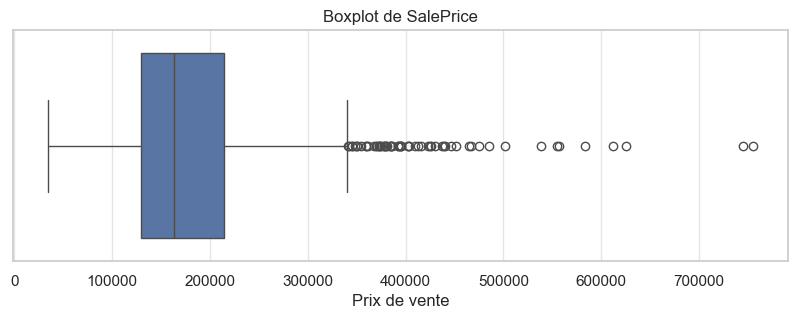

In [25]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df['SalePrice'], kde=True, ax=ax)
ax.set_title("Distribution de SalePrice")
ax.set_xlabel("Prix de vente")
ax.set_ylabel("Fréquence")
plt.show()

fig, ax = plt.subplots(figsize=(10, 3))
sns.boxplot(x=df['SalePrice'], ax=ax)
ax.set_title("Boxplot de SalePrice")
ax.set_xlabel("Prix de vente")
plt.show()

##### 4.2 Effet d’une transformation logarithmique

Une transformation logarithmique est souvent utilisée lorsque la variable cible est fortement asymétrique. Nous comparons ici la distribution brute de `SalePrice` avec celle de `log(SalePrice)` afin de vérifier si cette transformation rend la distribution plus régulière.

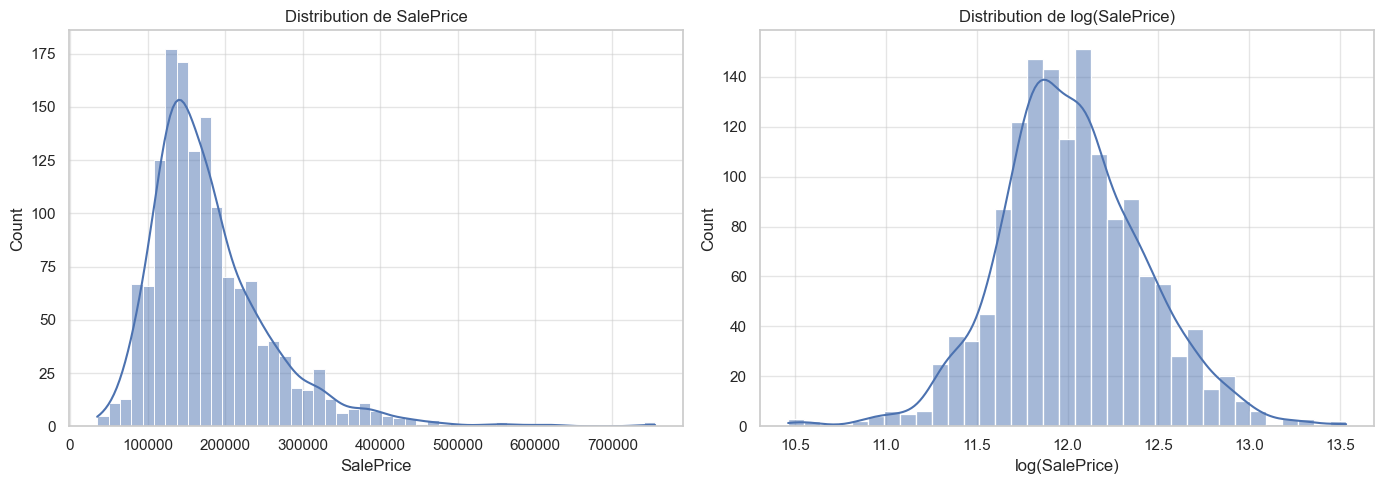

Skewness de SalePrice      : 1.883
Skewness de log(SalePrice) : 0.121


In [26]:
# Transformation logarithmique
df['SalePrice_log'] = np.log(df['SalePrice'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['SalePrice'], kde=True, ax=axes[0])
axes[0].set_title("Distribution de SalePrice")
axes[0].set_xlabel("SalePrice")

sns.histplot(df['SalePrice_log'], kde=True, ax=axes[1])
axes[1].set_title("Distribution de log(SalePrice)")
axes[1].set_xlabel("log(SalePrice)")

plt.tight_layout()
plt.show()

print(f"Skewness de SalePrice      : {df['SalePrice'].skew():.3f}")
print(f"Skewness de log(SalePrice) : {df['SalePrice_log'].skew():.3f}")

##### 4.3 Lecture de la distribution par quantiles

Les quantiles permettent de mieux situer les niveaux de prix dans le jeu de données. Ils offrent une lecture plus robuste que la moyenne seule et facilitent l’interprétation des segments de marché.

In [27]:
quantiles = df['SalePrice'].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).to_frame(name='SalePrice')
display(quantiles)

,SalePrice
0.01,61815.97
0.05,88000.00
0.25,129975.00
0.50,163000.00
0.75,214000.00
0.95,326100.00
0.99,442567.01


#####   4.4 Synthèse sur la cible

L’analyse de `SalePrice` montre que la variable cible présente une dispersion importante et une asymétrie marquée vers les grandes valeurs. La transformation logarithmique permet de rendre la distribution plus régulière, ce qui justifie son utilisation dans les étapes de modélisation. Les valeurs extrêmes observées seront étudiées plus en détail lors de l’analyse bivariée et du traitement des outliers.

#### 5. Analyse des valeurs manquantes

Avant toute préparation des données, il est nécessaire d’identifier les variables contenant des valeurs manquantes. Dans ce jeu de données, certains `NaN` correspondent à de véritables absences d’information, tandis que d’autres traduisent simplement l’absence d’un équipement, comme un garage, une piscine ou un sous-sol.

In [28]:
# Nombre et pourcentage de valeurs manquantes par variable
missing_count = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)

missing_df = pd.DataFrame({
    'missing_count': missing_count,
    'missing_pct': missing_pct
}).sort_values(by='missing_pct', ascending=False)

# On conserve uniquement les variables avec au moins une valeur manquante
missing_df = missing_df[missing_df['missing_count'] > 0]

display(missing_df)
print(f"Nombre de variables avec valeurs manquantes : {missing_df.shape[0]}")

,missing_count,missing_pct
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageQual,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


Nombre de variables avec valeurs manquantes : 19


##### 5.1 Variables les plus concernées par les valeurs manquantes

Nous représentons les variables les plus touchées par les valeurs manquantes afin d’identifier celles qui nécessiteront une attention particulière lors du prétraitement.

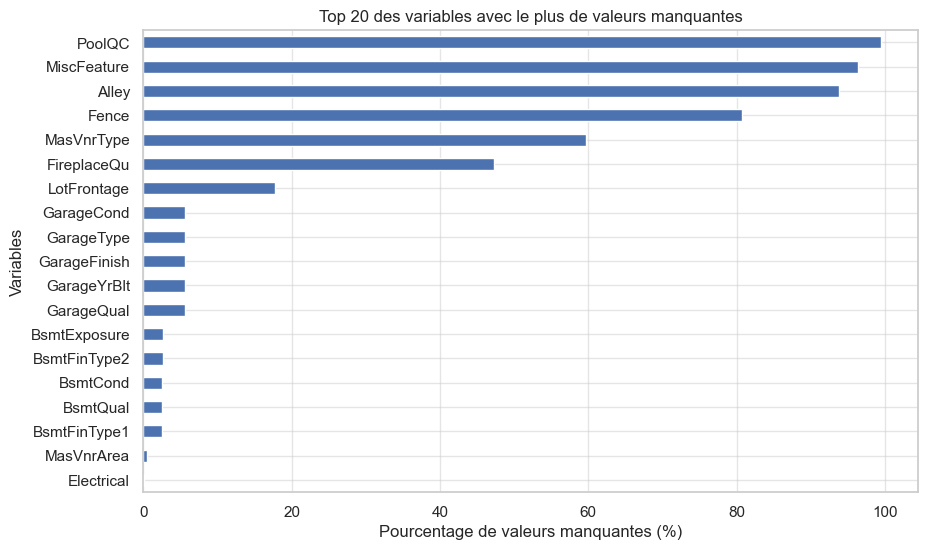

In [29]:
plt.figure(figsize=(10, 6))
missing_df.head(20)['missing_pct'].sort_values().plot(kind='barh')
plt.title("Top 20 des variables avec le plus de valeurs manquantes")
plt.xlabel("Pourcentage de valeurs manquantes (%)")
plt.ylabel("Variables")
plt.show()

##### 5.2 Valeurs manquantes et absence d’équipement

Dans le dataset, plusieurs valeurs manquantes ont une signification métier claire : elles indiquent non pas une donnée oubliée, mais l’absence d’un élément sur le bien immobilier. Il est donc important de distinguer ces cas des véritables données manquantes avant de choisir une stratégie d’imputation.

In [30]:
# Variables pour lesquelles NaN signifie généralement absence d'équipement
na_means_none = [
    'Alley',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'PoolQC',
    'Fence',
    'MiscFeature'
]

na_none_summary = pd.DataFrame({
    'missing_count': df[na_means_none].isnull().sum(),
    'missing_pct': (df[na_means_none].isnull().mean() * 100).round(2)
}).sort_values(by='missing_pct', ascending=False)

display(na_none_summary)

,missing_count,missing_pct
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
FireplaceQu,690,47.26
GarageQual,81,5.55
GarageType,81,5.55
GarageFinish,81,5.55
GarageCond,81,5.55
BsmtExposure,38,2.60


##### 5.3 Valeurs manquantes à examiner plus attentivement

Toutes les valeurs manquantes ne correspondent pas à une absence d’équipement. Certaines variables demandent une analyse plus prudente, car leurs `NaN` peuvent refléter une information réellement absente ou incomplète.

In [31]:
# Variables avec valeurs manquantes hors cas "absence d'équipement"
potentially_problematic_na = [col for col in missing_df.index if col not in na_means_none]

problematic_na_df = pd.DataFrame({
    'missing_count': df[potentially_problematic_na].isnull().sum(),
    'missing_pct': (df[potentially_problematic_na].isnull().mean() * 100).round(2),
    'dtype': df[potentially_problematic_na].dtypes.astype(str)
}).sort_values(by='missing_pct', ascending=False)

display(problematic_na_df)

,missing_count,missing_pct,dtype
MasVnrType,872,59.73,str
LotFrontage,259,17.74,float64
GarageYrBlt,81,5.55,float64
MasVnrArea,8,0.55,float64
Electrical,1,0.07,str


##### 5.4 Synthèse sur les valeurs manquantes

L’analyse des valeurs manquantes met en évidence deux situations distinctes : d’une part, des absences d’équipement explicitement codées par des `NaN`, et d’autre part, quelques variables nécessitant une imputation plus prudente. Cette étape est essentielle pour éviter des traitements incorrects et préparer un prétraitement cohérent avec la signification des données.

#### 6. Analyse univariée des variables

L’analyse univariée consiste à étudier chaque variable séparément. Nous commençons par les variables numériques afin d’examiner leur distribution, leur dispersion et la présence éventuelle de valeurs extrêmes.

In [32]:
# Variables numériques (hors identifiant et cible/log-cible)
num_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_features = [col for col in num_features if col not in ['Id', 'SalePrice', 'SalePrice_log']]

print(f"Nombre de variables numériques analysées : {len(num_features)}")
print(num_features)

Nombre de variables numériques analysées : 36
['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']


##### 6.1.1 Statistiques descriptives

Nous calculons les statistiques descriptives des variables numériques pour obtenir une première lecture de leur niveau, de leur dispersion et de leur amplitude.

In [33]:
num_summary = df[num_features].describe().T
num_summary['median'] = df[num_features].median()
num_summary['skew'] = df[num_features].skew()
num_summary['kurtosis'] = df[num_features].kurt()

display(num_summary.sort_values(by='std', ascending=False))

,count,mean,std,min,25%,50%,75%,max,median,skew,kurtosis
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0,9478.5,12.207688,203.243271
GrLivArea,1460.0,1515.463699,525.480383,334.0,1129.50,1464.0,1776.75,5642.0,1464.0,1.366560,4.895121
MiscVal,1460.0,43.489041,496.123024,0.0,0.00,0.0,0.00,15500.0,0.0,24.476794,701.003342
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0,383.5,1.685503,11.118236
BsmtUnfSF,1460.0,567.240411,441.866955,0.0,223.00,477.5,808.00,2336.0,477.5,0.920268,0.474994
TotalBsmtSF,1460.0,1057.429452,438.705324,0.0,795.75,991.5,1298.25,6110.0,991.5,1.524255,13.250483
2ndFlrSF,1460.0,346.992466,436.528436,0.0,0.00,0.0,728.00,2065.0,0.0,0.813030,-0.553464
1stFlrSF,1460.0,1162.626712,386.587738,334.0,882.00,1087.0,1391.25,4692.0,1087.0,1.376757,5.745841
GarageArea,1460.0,472.980137,213.804841,0.0,334.50,480.0,576.00,1418.0,480.0,0.179981,0.917067
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0,0.0,2.669084,10.082417


##### 6.1.2 Distribution de quelques variables numériques clés

Nous visualisons plusieurs variables numériques importantes afin d’observer leur forme de distribution et d’identifier d’éventuelles asymétries ou concentrations particulières.

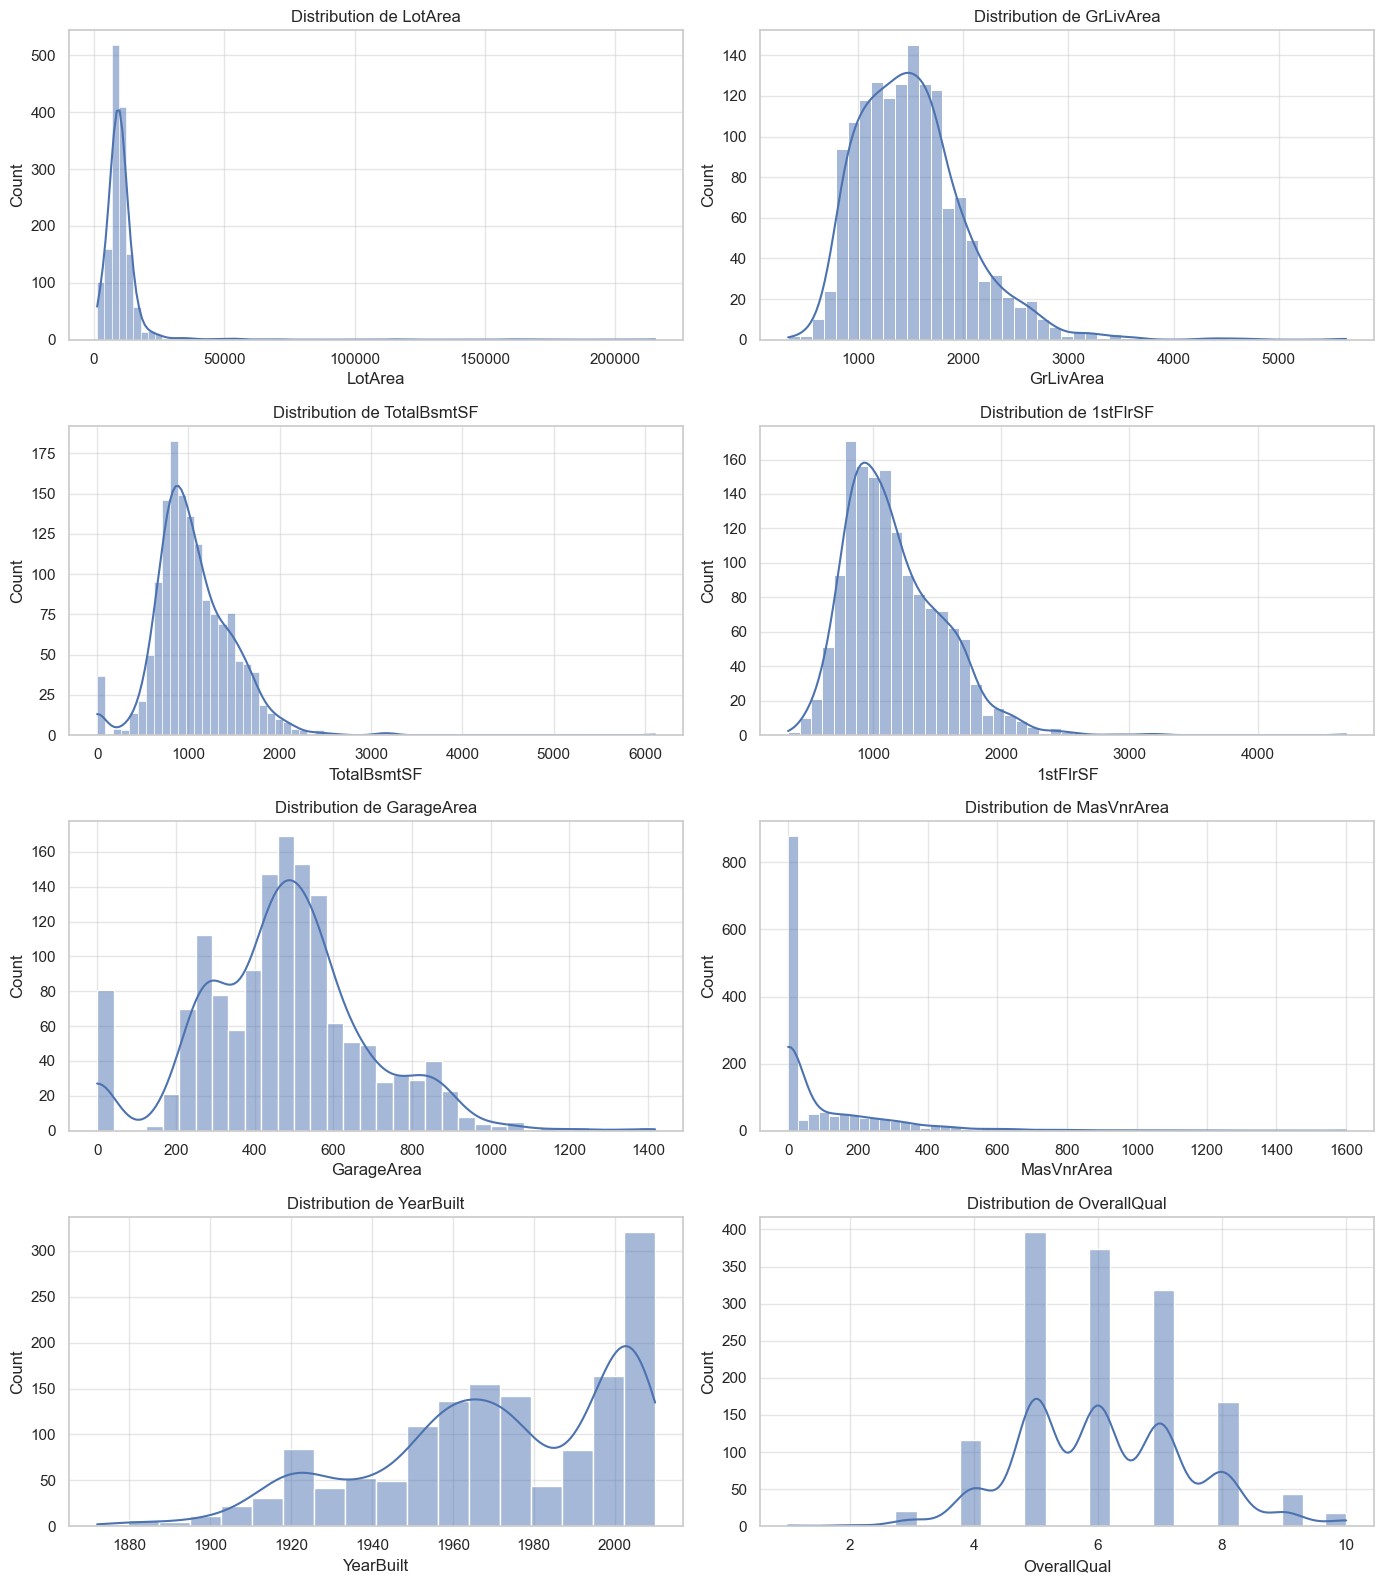

In [34]:
key_num_vars = [
    'LotArea', 'GrLivArea', 'TotalBsmtSF', '1stFlrSF',
    'GarageArea', 'MasVnrArea', 'YearBuilt', 'OverallQual'
]

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(key_num_vars):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution de {col}")
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

##### 6.1.3 Détection visuelle des valeurs extrêmes

Les boxplots permettent de repérer rapidement les variables numériques présentant des valeurs très éloignées du cœur de la distribution. Cette étape aide à préparer l’analyse future des outliers.

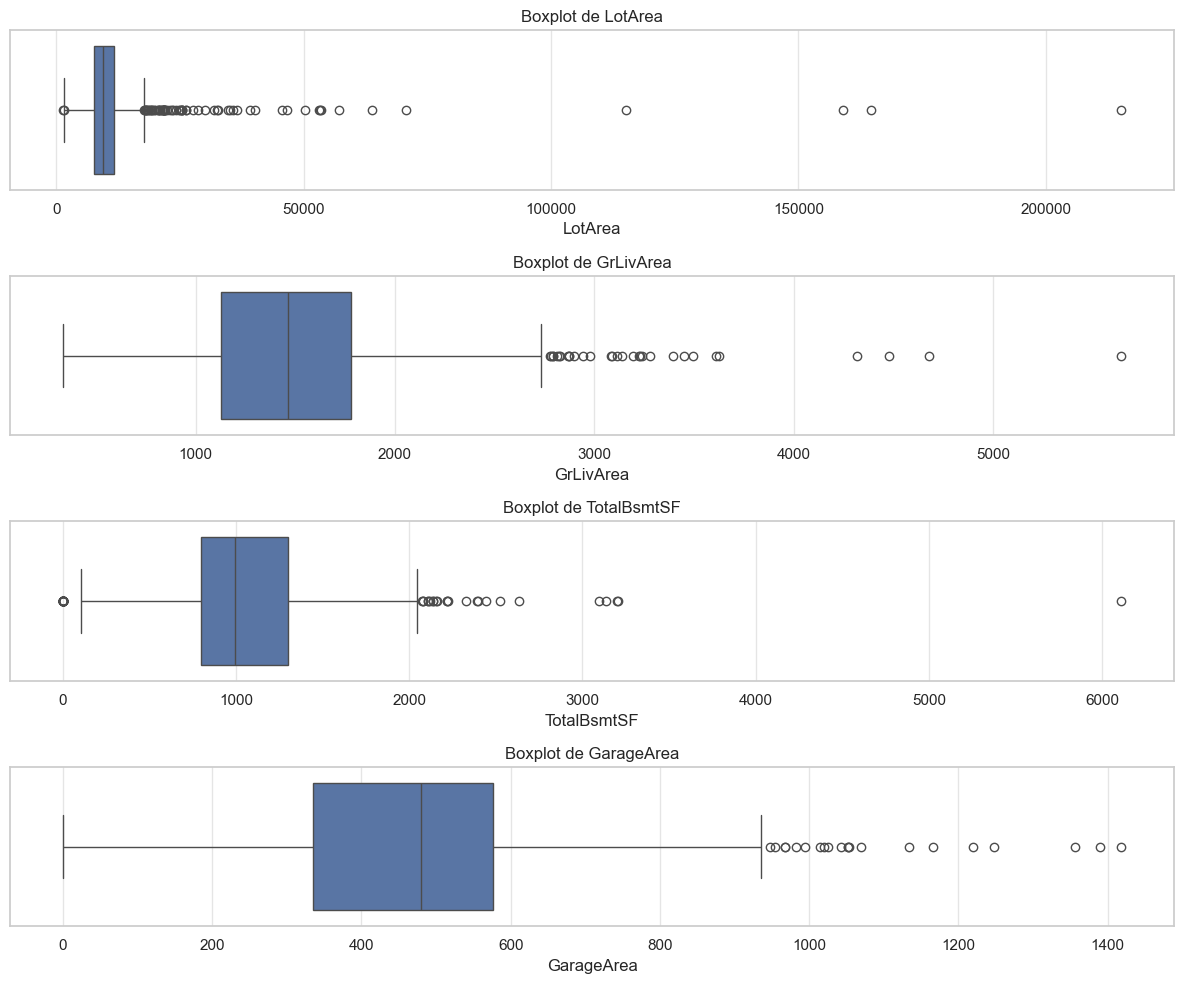

In [35]:
boxplot_vars = ['LotArea', 'GrLivArea', 'TotalBsmtSF', 'GarageArea']

fig, axes = plt.subplots(len(boxplot_vars), 1, figsize=(12, 10))

for i, col in enumerate(boxplot_vars):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f"Boxplot de {col}")
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

#### 6.2 Analyse des variables catégorielles

Nous poursuivons l’analyse univariée avec les variables catégorielles. L’objectif est d’identifier les modalités les plus fréquentes, les déséquilibres éventuels et la présence de catégories rares.

In [36]:
cat_features = df.select_dtypes(include=['object', 'string']).columns.tolist()

print(f"Nombre de variables catégorielles analysées : {len(cat_features)}")
print(cat_features)

Nombre de variables catégorielles analysées : 43
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


##### 6.2.1 Cardinalité des variables catégorielles

Nous examinons le nombre de modalités par variable catégorielle afin de distinguer les variables simples de celles qui présentent une forte diversité de catégories.

In [37]:
cat_cardinality = pd.DataFrame({
    'n_unique': df[cat_features].nunique(),
    'missing_count': df[cat_features].isnull().sum()
}).sort_values(by='n_unique', ascending=False)

display(cat_cardinality)

,n_unique,missing_count
Neighborhood,25,0
Exterior2nd,16,0
Exterior1st,15,0
Condition1,9,0
SaleType,9,0
HouseStyle,8,0
RoofMatl,8,0
Condition2,8,0
Functional,7,0
BsmtFinType2,6,38


##### 6.2.2 Fréquence des principales catégories

Nous représentons la fréquence de plusieurs variables catégorielles importantes afin de visualiser les modalités dominantes dans le jeu de données.

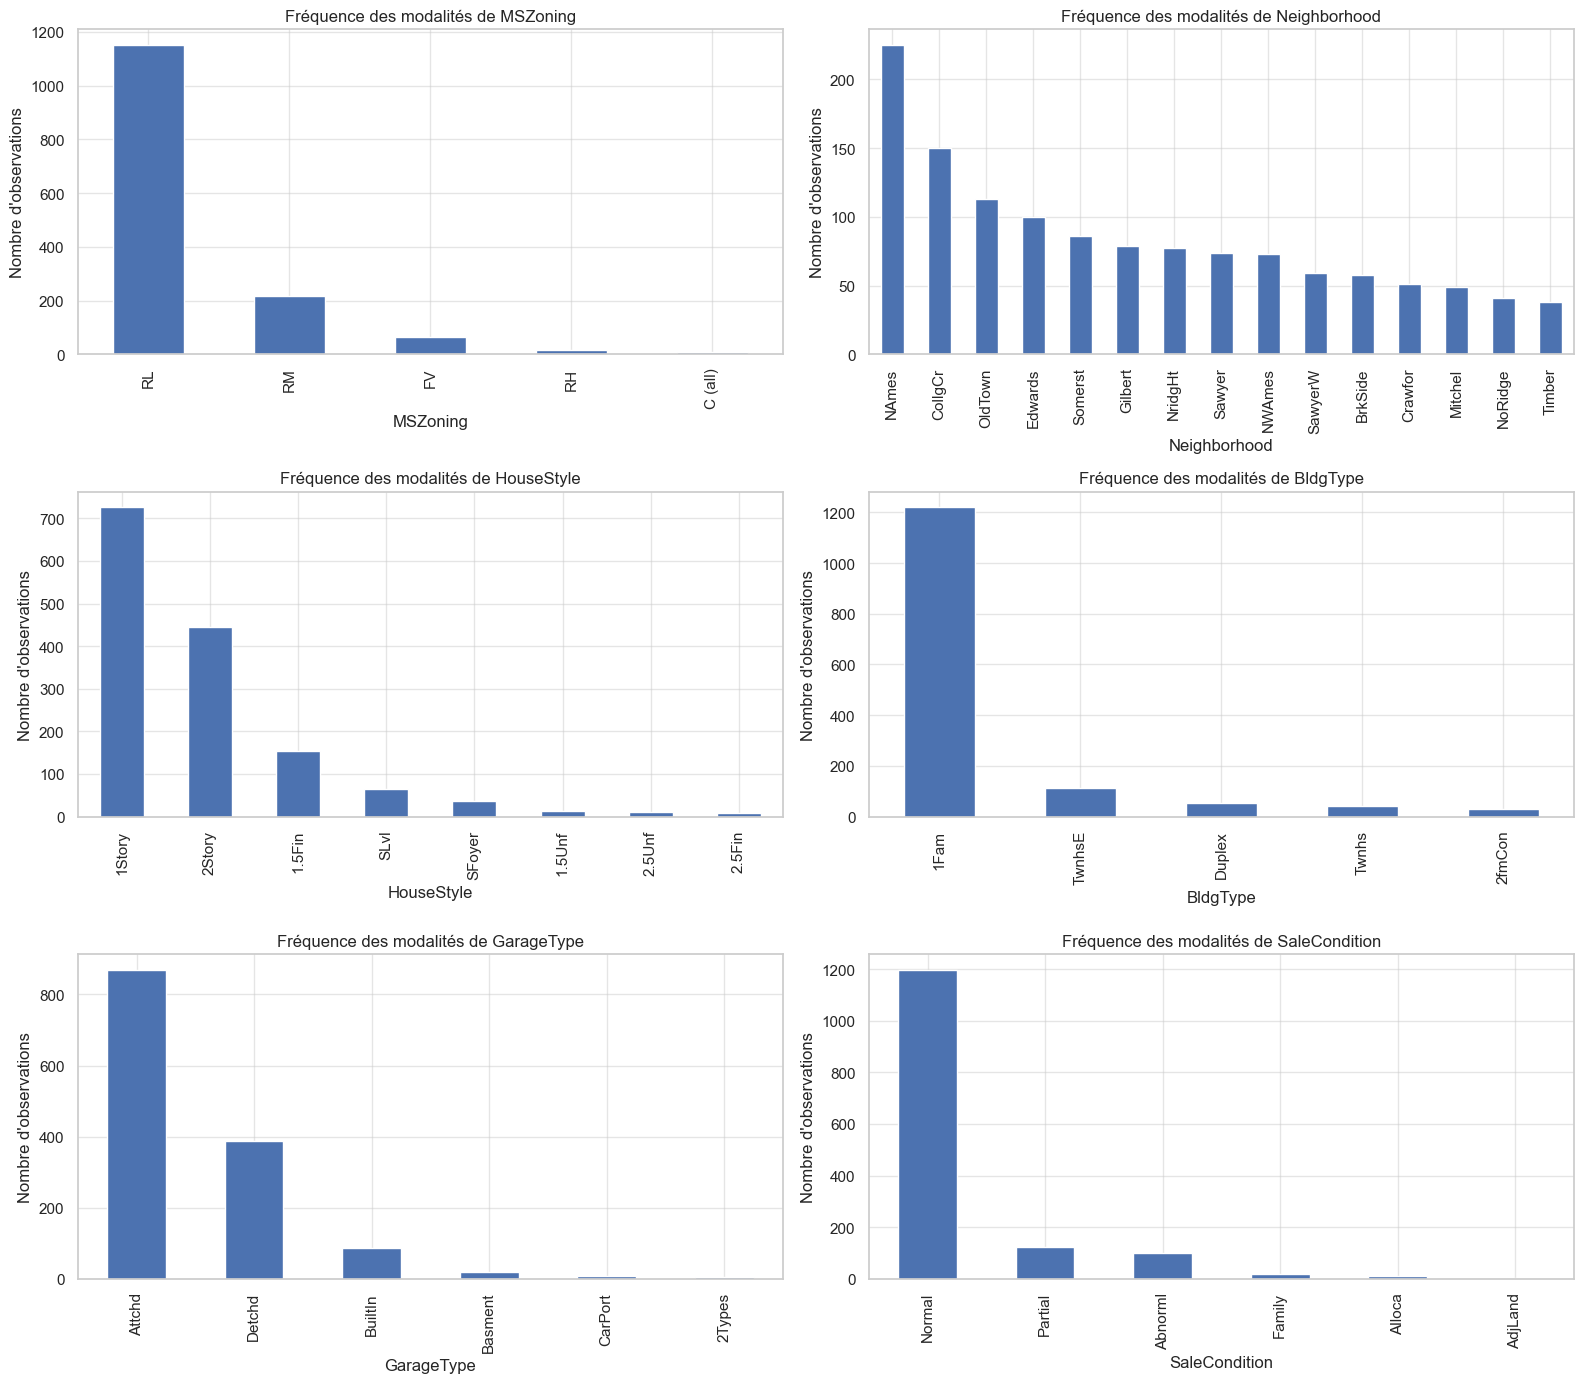

In [38]:
key_cat_vars = ['MSZoning', 'Neighborhood', 'HouseStyle', 'BldgType', 'GarageType', 'SaleCondition']

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(key_cat_vars):
    df[col].value_counts().head(15).plot(kind='bar', ax=axes[i])
    axes[i].set_title(f"Fréquence des modalités de {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Nombre d'observations")

plt.tight_layout()
plt.show()

##### 6.2.3 Variables catégorielles ordinales

Certaines variables catégorielles représentent en réalité des niveaux ordonnés de qualité ou d’état. Cette particularité devra être prise en compte lors du prétraitement, car ces variables contiennent une information hiérarchique importante.

In [39]:
ordinal_candidates = [
    'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
    'HeatingQC', 'KitchenQual', 'FireplaceQu',
    'GarageQual', 'GarageCond', 'PoolQC'
]

for col in ordinal_candidates:
    if col in df.columns:
        print(f"\n{col}")
        print(df[col].value_counts(dropna=False))


ExterQual
ExterQual
TA    906
Gd    488
Ex     52
Fa     14
Name: count, dtype: int64

ExterCond
ExterCond
TA    1282
Gd     146
Fa      28
Ex       3
Po       1
Name: count, dtype: int64

BsmtQual
BsmtQual
TA     649
Gd     618
Ex     121
NaN     37
Fa      35
Name: count, dtype: int64

BsmtCond
BsmtCond
TA     1311
Gd       65
Fa       45
NaN      37
Po        2
Name: count, dtype: int64

HeatingQC
HeatingQC
Ex    741
TA    428
Gd    241
Fa     49
Po      1
Name: count, dtype: int64

KitchenQual
KitchenQual
TA    735
Gd    586
Ex    100
Fa     39
Name: count, dtype: int64

FireplaceQu
FireplaceQu
NaN    690
Gd     380
TA     313
Fa      33
Ex      24
Po      20
Name: count, dtype: int64

GarageQual
GarageQual
TA     1311
NaN      81
Fa       48
Gd       14
Ex        3
Po        3
Name: count, dtype: int64

GarageCond
GarageCond
TA     1326
NaN      81
Fa       35
Gd        9
Po        7
Ex        2
Name: count, dtype: int64

PoolQC
PoolQC
NaN    1453
Gd        3
Ex        2
Fa      

##### 6.3 Synthèse de l’analyse univariée

L’analyse univariée met en évidence la diversité des profils présents dans le dataset. Les variables numériques présentent souvent des distributions asymétriques et parfois des valeurs extrêmes, tandis que les variables catégorielles révèlent des modalités dominantes ainsi que quelques catégories rares. Cette étape prépare l’analyse des liens entre les caractéristiques des biens et leur prix de vente.

#### 7. Analyse bivariée avec la variable cible

Après avoir étudié les variables individuellement, nous analysons maintenant leur relation avec `SalePrice`. L’objectif est d’identifier les caractéristiques les plus liées au prix de vente et de repérer d’éventuelles tendances, corrélations ou observations atypiques.

In [40]:
# Corrélations des variables numériques avec SalePrice
num_for_corr = df.select_dtypes(include=['int64', 'float64']).drop(columns=['SalePrice_log'], errors='ignore')
corr_with_target = num_for_corr.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)

display(corr_with_target.to_frame(name='correlation_with_SalePrice'))

,correlation_with_SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897


##### 7.1.1 Variables numériques les plus corrélées au prix

Nous examinons les variables numériques les plus corrélées positivement et négativement à `SalePrice` afin de repérer les facteurs les plus influents dans le jeu de données.

In [41]:
corr_no_target = corr_with_target.drop('SalePrice', errors='ignore')
top_pos_corr = corr_no_target.sort_values(ascending=False).head(10)
top_neg_corr = corr_no_target.sort_values(ascending=True).head(10)

print("Top corrélations positives avec SalePrice :")
display(top_pos_corr.to_frame())

print("Top corrélations les plus faibles / négatives avec SalePrice :")
display(top_neg_corr.to_frame())

Top corrélations positives avec SalePrice :


,SalePrice
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897
YearRemodAdd,0.507101


Top corrélations les plus faibles / négatives avec SalePrice :


,SalePrice
KitchenAbvGr,-0.135907
EnclosedPorch,-0.128578
MSSubClass,-0.084284
OverallCond,-0.077856
YrSold,-0.028923
LowQualFinSF,-0.025606
Id,-0.021917
MiscVal,-0.021190
BsmtHalfBath,-0.016844
BsmtFinSF2,-0.011378


##### 7.1.2 Matrice de corrélation des variables les plus liées au prix

Nous représentons la matrice de corrélation des variables numériques les plus liées à `SalePrice`. Cette visualisation permet de voir à la fois leur lien avec la cible et les redondances éventuelles entre variables explicatives.

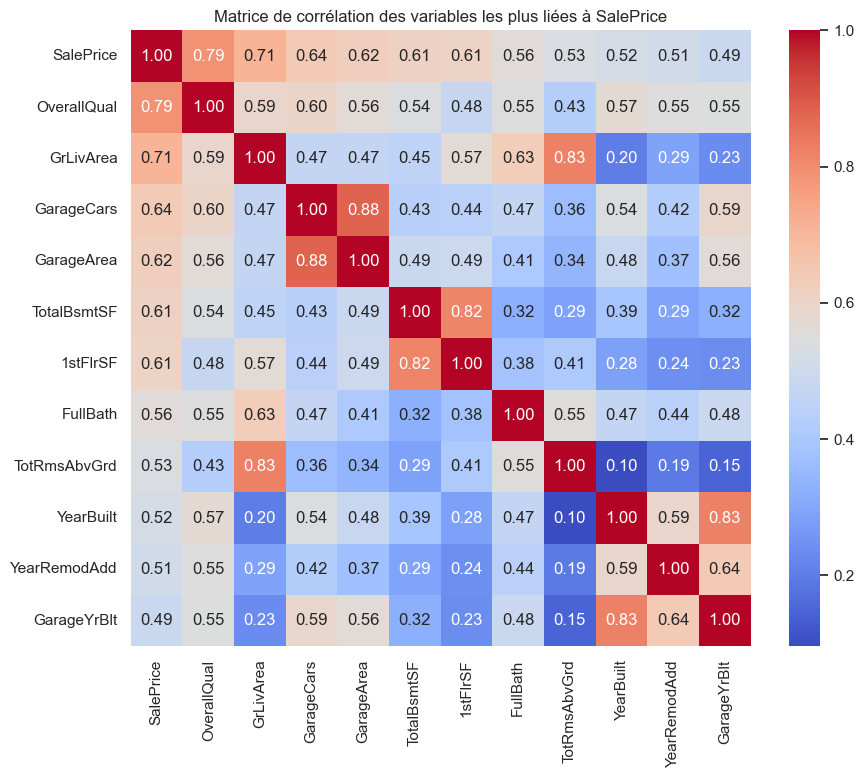

In [42]:
top_corr_vars = corr_with_target.abs().sort_values(ascending=False).head(12).index

plt.figure(figsize=(10, 8))
sns.heatmap(df[top_corr_vars].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matrice de corrélation des variables les plus liées à SalePrice")
plt.show()

##### 7.1.3 Visualisation de quelques relations numériques avec le prix

Nous représentons plusieurs variables numériques importantes en fonction de `SalePrice` afin d’observer la forme de leur relation avec le prix de vente.

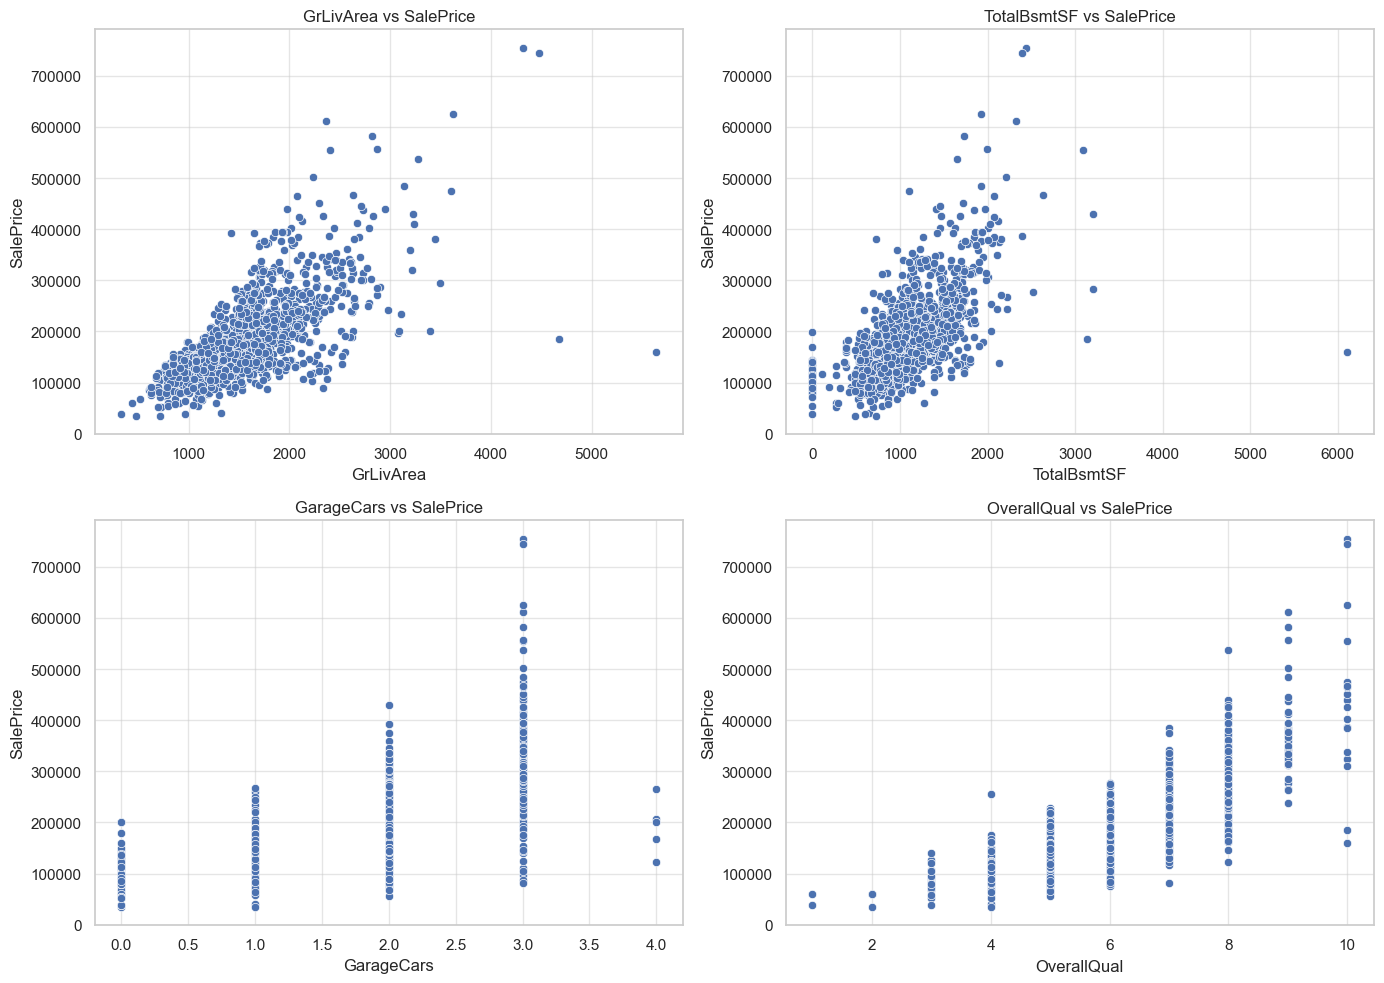

In [43]:
scatter_vars = ['GrLivArea', 'TotalBsmtSF', 'GarageCars', 'OverallQual']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(scatter_vars):
    sns.scatterplot(data=df, x=col, y='SalePrice', ax=axes[i])
    axes[i].set_title(f"{col} vs SalePrice")

plt.tight_layout()
plt.show()

#### 7.2 Analyse des variables catégorielles par rapport au prix

Nous étudions maintenant comment `SalePrice` varie selon certaines variables catégorielles. Les comparaisons de médianes permettent de repérer les catégories associées à des maisons plus chères ou moins chères.

##### 7.2.1 Comparaison visuelle des prix selon certaines catégories

Les boxplots permettent de comparer la distribution de `SalePrice` selon différentes catégories et d’observer les écarts de niveau de prix entre groupes.

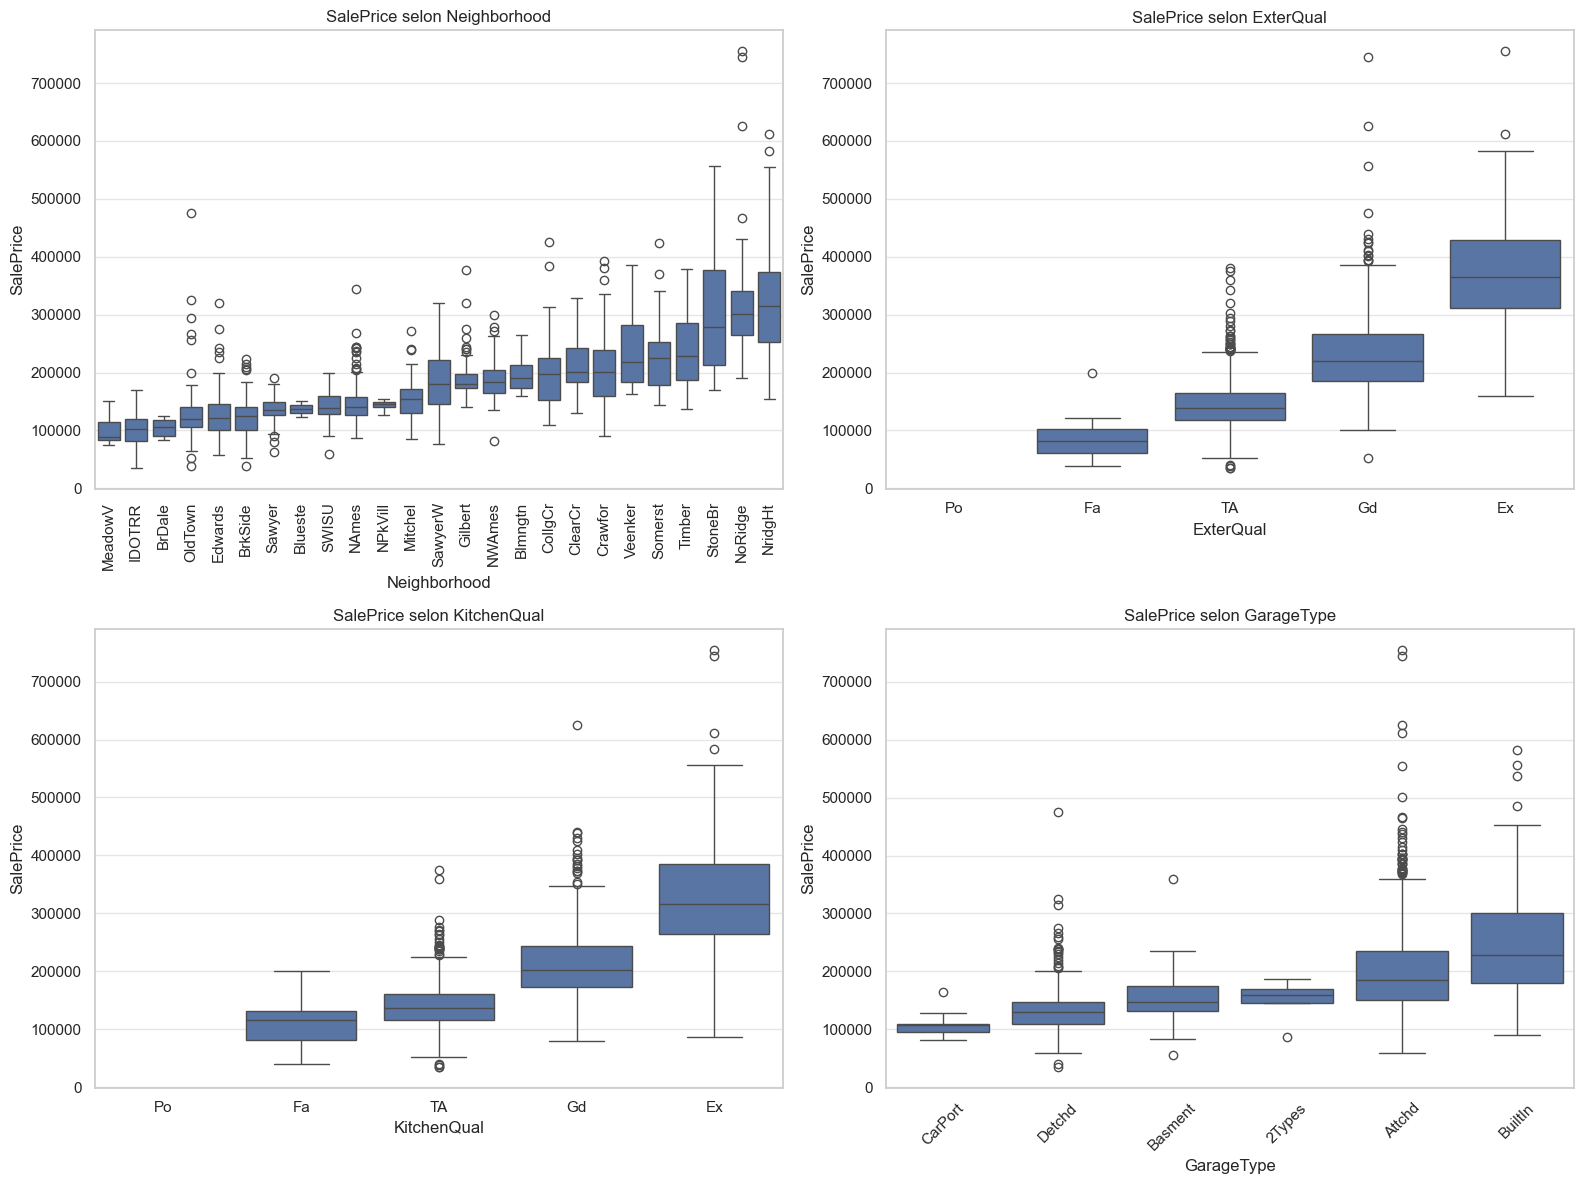

In [44]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Neighborhood
neigh_order = df.groupby('Neighborhood')['SalePrice'].median().sort_values().index
sns.boxplot(data=df, x='Neighborhood', y='SalePrice', order=neigh_order, ax=axes[0, 0])
axes[0, 0].set_title("SalePrice selon Neighborhood")
axes[0, 0].tick_params(axis='x', rotation=90)

# ExterQual
qual_order = ['Po', 'Fa', 'TA', 'Gd', 'Ex']
sns.boxplot(data=df, x='ExterQual', y='SalePrice', order=qual_order, ax=axes[0, 1])
axes[0, 1].set_title("SalePrice selon ExterQual")

# KitchenQual
sns.boxplot(data=df, x='KitchenQual', y='SalePrice', order=qual_order, ax=axes[1, 0])
axes[1, 0].set_title("SalePrice selon KitchenQual")

# GarageType
garage_order = df.groupby('GarageType')['SalePrice'].median().sort_values().index
sns.boxplot(data=df, x='GarageType', y='SalePrice', order=garage_order, ax=axes[1, 1])
axes[1, 1].set_title("SalePrice selon GarageType")
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

##### 7.3 Focus sur quelques variables particulièrement explicatives

Certaines variables apparaissent comme particulièrement liées au prix de vente. Nous les examinons plus en détail afin de mieux comprendre leur effet et leur intérêt pour la modélisation.

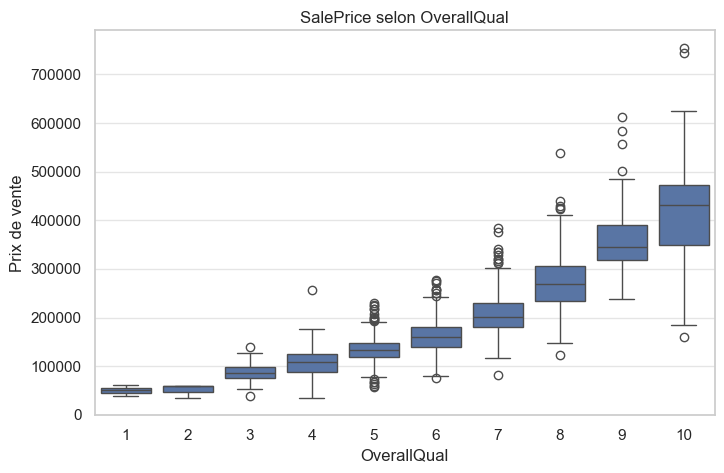

In [45]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='OverallQual', y='SalePrice')
plt.title("SalePrice selon OverallQual")
plt.xlabel("OverallQual")
plt.ylabel("Prix de vente")
plt.show()

#### 7.4 Synthèse de l’analyse bivariée

L’analyse bivariée met en évidence plusieurs facteurs fortement liés au prix de vente, en particulier la qualité globale du bien, la surface habitable, certaines caractéristiques du garage et la localisation. Elle révèle également des écarts marqués entre catégories ainsi que quelques observations atypiques, qui seront étudiées plus en détail dans la section consacrée aux corrélations et aux outliers.

#### 8. Corrélations et redondances

Après avoir étudié les liens entre les variables et `SalePrice`, nous examinons ici les corrélations entre variables numériques explicatives. L’objectif est d’identifier d’éventuelles redondances, notamment entre variables de surface ou d’équipement.

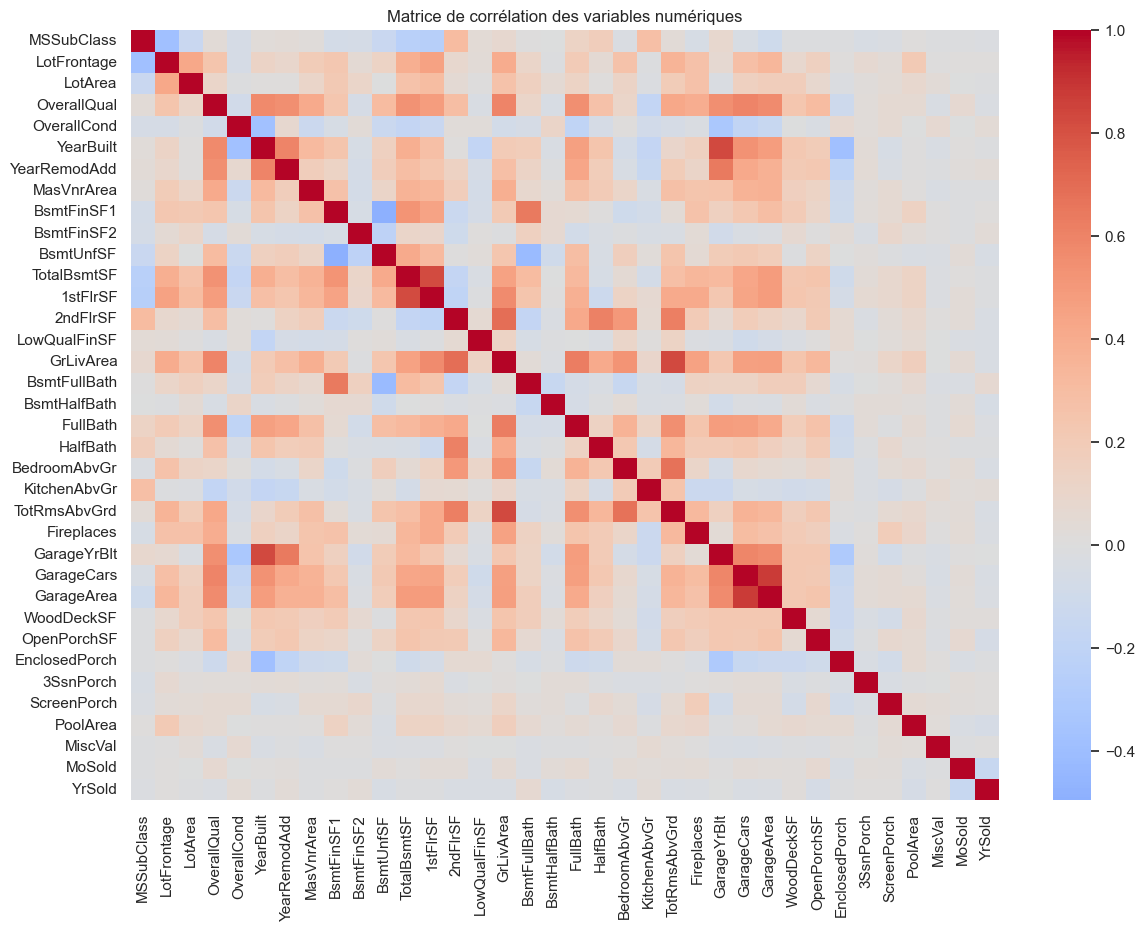

In [46]:
# Variables numériques hors cible
num_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_features = [col for col in num_features if col not in ['Id', 'SalePrice', 'SalePrice_log']]

corr_matrix = df[num_features].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title("Matrice de corrélation des variables numériques")
plt.show()

##### 8.1 Paires de variables les plus corrélées

Nous listons les couples de variables numériques les plus corrélés afin de repérer les redondances potentielles dans les données.

In [47]:
# Extraction des corrélations fortes entre variables explicatives
corr_pairs = corr_matrix.abs().unstack().reset_index()
corr_pairs.columns = ['var1', 'var2', 'corr']

# Suppression des doublons et des auto-corrélations
corr_pairs = corr_pairs[corr_pairs['var1'] != corr_pairs['var2']]
corr_pairs['pair'] = corr_pairs.apply(lambda x: tuple(sorted([x['var1'], x['var2']])), axis=1)
corr_pairs = corr_pairs.drop_duplicates(subset='pair').drop(columns='pair')

# Tri décroissant
top_corr_pairs = corr_pairs.sort_values(by='corr', ascending=False)

display(top_corr_pairs.head(15))

,var1,var2,corr
926,GarageCars,GarageArea,0.882475
204,YearBuilt,GarageYrBlt,0.825667
562,GrLivArea,TotRmsAbvGrd,0.825489
408,TotalBsmtSF,1stFlrSF,0.819530
483,2ndFlrSF,GrLivArea,0.687501
742,BedroomAbvGr,TotRmsAbvGrd,0.676620
304,BsmtFinSF1,BsmtFullBath,0.649212
240,YearRemodAdd,GarageYrBlt,0.642277
558,GrLivArea,FullBath,0.630012
490,2ndFlrSF,TotRmsAbvGrd,0.616423


#### 8.2 Focus sur quelques variables très corrélées

Nous visualisons quelques relations fortes entre variables pour mieux comprendre les redondances observées dans la matrice de corrélation.

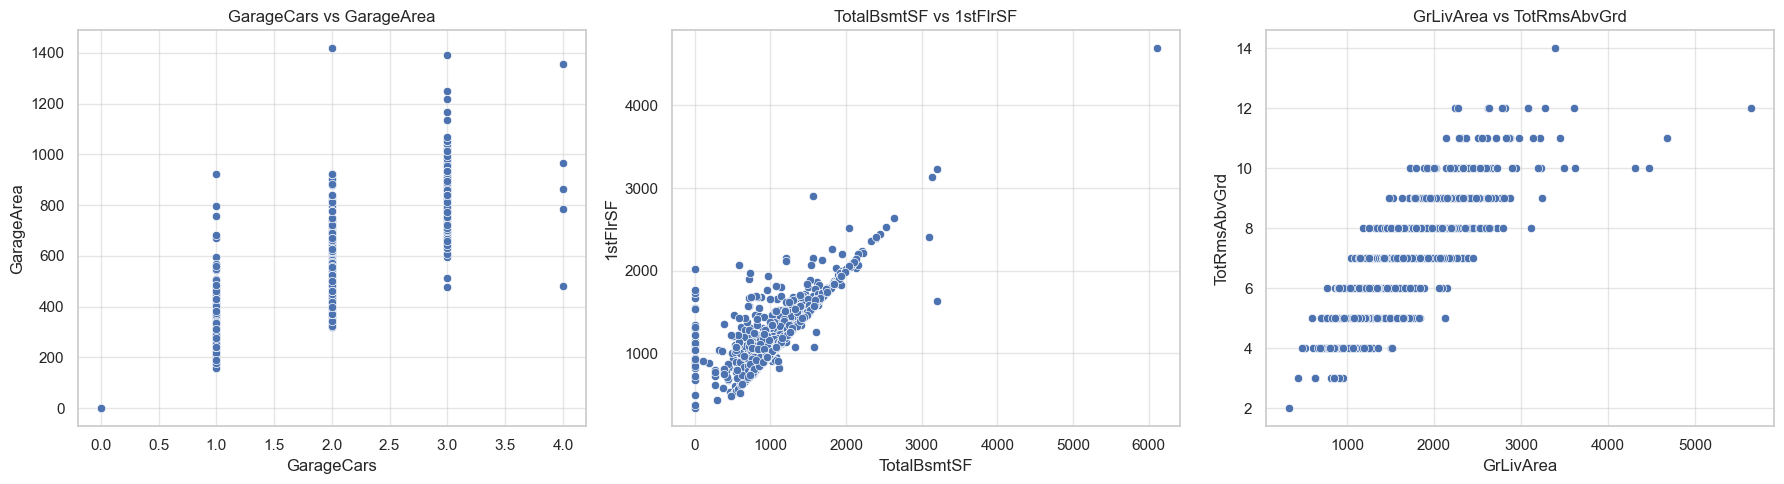

In [48]:
selected_pairs = [
    ('GarageCars', 'GarageArea'),
    ('TotalBsmtSF', '1stFlrSF'),
    ('GrLivArea', 'TotRmsAbvGrd')
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (x_col, y_col) in enumerate(selected_pairs):
    sns.scatterplot(data=df, x=x_col, y=y_col, ax=axes[i])
    axes[i].set_title(f"{x_col} vs {y_col}")

plt.tight_layout()
plt.show()

#### 8.3 Synthèse sur les corrélations

L’analyse met en évidence plusieurs redondances entre variables explicatives, en particulier autour des surfaces, du garage et de certaines mesures structurelles du bien. Ces liens n’empêchent pas leur utilisation, mais ils devront être gardés à l’esprit lors de l’interprétation des modèles.

#### 9. Outliers et observations atypiques

Nous terminons l’EDA par l’identification de quelques observations atypiques. L’objectif n’est pas de supprimer automatiquement ces points, mais de repérer les cas qui s’écartent fortement des tendances générales et qui pourraient influencer la modélisation.

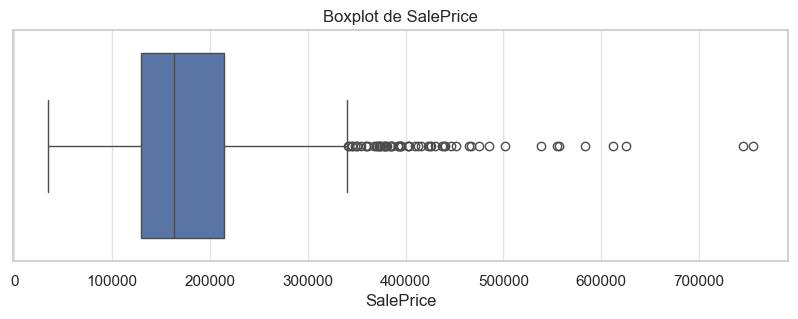

Nombre d'outliers détectés sur SalePrice (règle IQR) : 61


,Id,SalePrice
691,692,755000
1182,1183,745000
1169,1170,625000
898,899,611657
803,804,582933
1046,1047,556581
440,441,555000
769,770,538000
178,179,501837
798,799,485000


In [49]:
# Boxplot de la cible
plt.figure(figsize=(10, 3))
sns.boxplot(x=df['SalePrice'])
plt.title("Boxplot de SalePrice")
plt.xlabel("SalePrice")
plt.show()

# Seuil IQR pour repérage simple
Q1 = df['SalePrice'].quantile(0.25)
Q3 = df['SalePrice'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

saleprice_outliers = df[(df['SalePrice'] < lower_bound) | (df['SalePrice'] > upper_bound)]

print(f"Nombre d'outliers détectés sur SalePrice (règle IQR) : {saleprice_outliers.shape[0]}")
display(saleprice_outliers[['Id', 'SalePrice']].sort_values(by='SalePrice', ascending=False).head(10))

#### 9.1 Observation des atypies sur les variables explicatives majeures

Nous examinons ensuite quelques variables importantes pour repérer des observations très éloignées de la distribution centrale, notamment sur les surfaces.

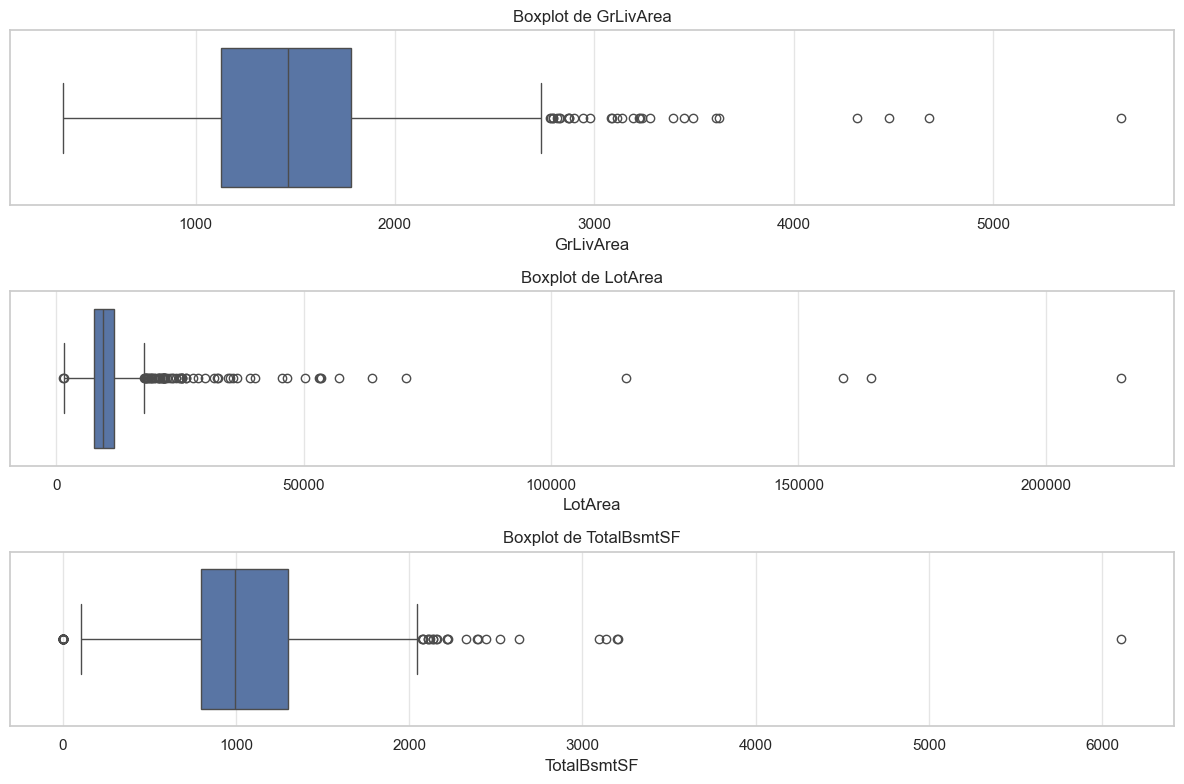

In [50]:
outlier_vars = ['GrLivArea', 'LotArea', 'TotalBsmtSF']

fig, axes = plt.subplots(len(outlier_vars), 1, figsize=(12, 8))

for i, col in enumerate(outlier_vars):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f"Boxplot de {col}")
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

#### 9.2 Focus sur les observations atypiques de `GrLivArea`

La relation entre `GrLivArea` et `SalePrice` permet d’identifier visuellement certaines maisons très grandes dont le prix reste relativement faible. Ces cas sont particulièrement importants pour la suite.

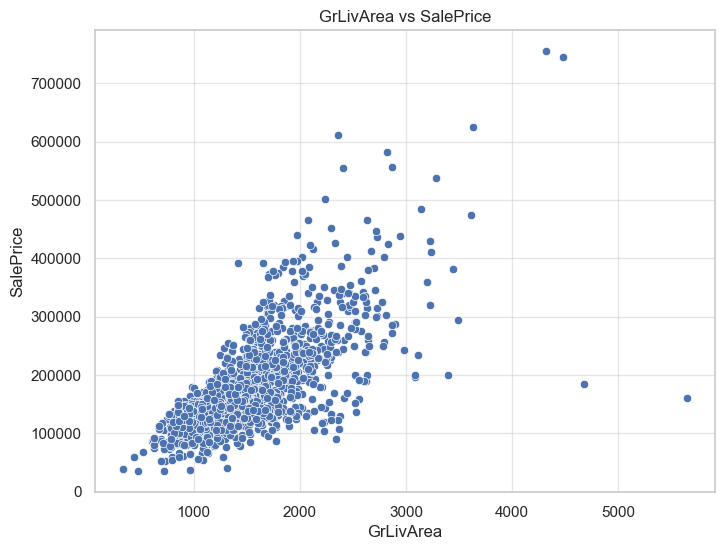

,Id,GrLivArea,SalePrice,OverallQual,Neighborhood
1298,1299,5642,160000,10,Edwards
523,524,4676,184750,10,Edwards
1182,1183,4476,745000,10,NoRidge
691,692,4316,755000,10,NoRidge


In [51]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='GrLivArea', y='SalePrice')
plt.title("GrLivArea vs SalePrice")
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.show()

# Affichage des très grandes surfaces
large_houses = df[df['GrLivArea'] > 4000][['Id', 'GrLivArea', 'SalePrice', 'OverallQual', 'Neighborhood']]
display(large_houses.sort_values(by='GrLivArea', ascending=False))

#### 9.4 Synthèse sur les outliers

L’analyse met en évidence plusieurs observations atypiques, principalement sur `SalePrice` et certaines variables de surface comme `GrLivArea`. Ces points ne doivent pas être supprimés automatiquement : ils doivent être interprétés au regard de leur cohérence métier et de leur impact sur les performances du modèle.

### Phase 2 : Nettoyage des données

#### 1. Chargement des données d'entraînement

In [52]:
df = pd.read_csv('./data/train.csv', sep=',')

#### 2. Suppression des observations atypiques

Sur la base de l’analyse exploratoire, nous retirons ici les maisons présentant une surface habitable (`GrLivArea`) supérieure à 4000, car elles s’écartent nettement de la tendance générale observée.

In [53]:
outliers_index = df[df['GrLivArea'] > 4000].index
print(f"Nombre de points supprimés : {len(outliers_index)}")

df_cleaned = df.drop(outliers_index).copy()
print("Dimensions après suppression :", df_cleaned.shape)

Nombre de points supprimés : 4
Dimensions après suppression : (1456, 81)


#### 3. Transformation logarithmique de la cible

La variable `SalePrice` présente une asymétrie à droite. Nous appliquons donc une transformation logarithmique afin de réduire l’effet des valeurs très élevées et de stabiliser l’apprentissage des modèles.

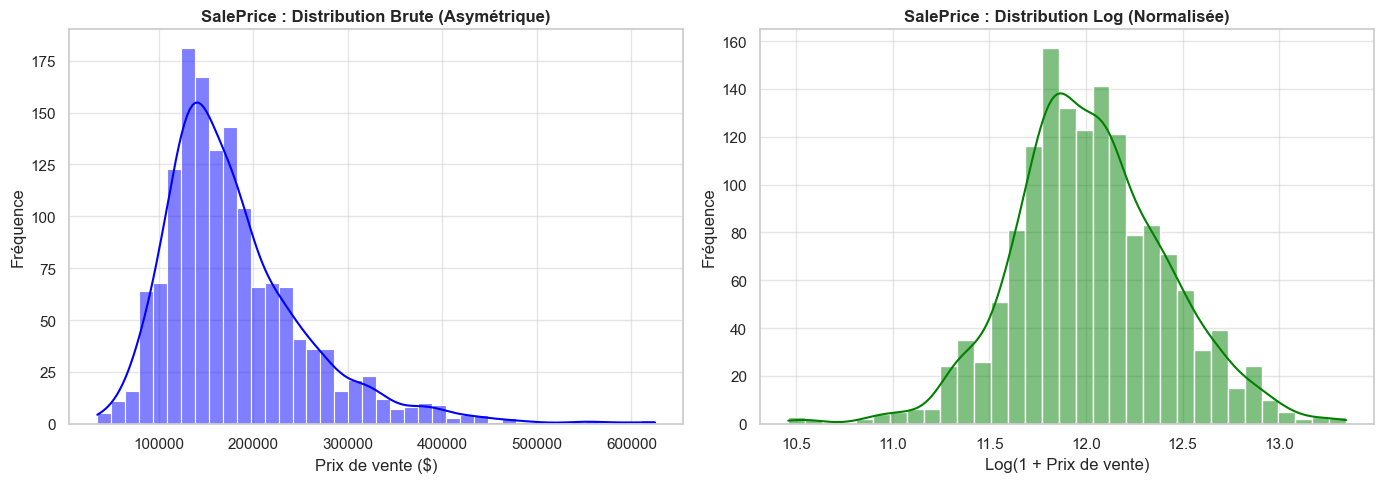

Statistiques après nettoyage et transformation :


,GrLivArea,SalePrice,SalePrice_log
count,1456.000000,1456.000000,1456.000000
mean,1506.502060,180151.233516,12.021950
std,496.815378,76696.592530,0.396077
min,334.000000,34900.000000,10.460271
25%,1128.000000,129900.000000,11.774528
50%,1458.500000,163000.000000,12.001512
75%,1775.250000,214000.000000,12.273736
max,3627.000000,625000.000000,13.345509


In [54]:
# Application de la transformation logarithmique sur la cible
# (Indispensable pour la métrique RMSE sur logs)
# ex: log1p(150 000) = 11.91, log1p(5 000 000) = 15.42
df_cleaned['SalePrice_log'] = np.log1p(df_cleaned['SalePrice'])

# Création d'une figure avec 2 colonnes (1 ligne, 2 graphiques)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Graphique 1 : Distribution Avant (SalePrice Brut) ---
sns.histplot(df_cleaned['SalePrice'], kde=True, color="blue", ax=ax1)
ax1.set_title("SalePrice : Distribution Brute (Asymétrique)", fontweight='bold')
ax1.set_xlabel("Prix de vente ($)")
ax1.set_ylabel("Fréquence")

# --- Graphique 2 : Distribution Après (SalePrice Log) ---
sns.histplot(df_cleaned['SalePrice_log'], kde=True, color="green", ax=ax2)
ax2.set_title("SalePrice : Distribution Log (Normalisée)", fontweight='bold')
ax2.set_xlabel("Log(1 + Prix de vente)")
ax2.set_ylabel("Fréquence")

# Ajustement pour éviter que les titres ne se chevauchent
plt.tight_layout()
plt.show()

print("Statistiques après nettoyage et transformation :")
display(df_cleaned[['GrLivArea', 'SalePrice', 'SalePrice_log']].describe())

#### 4. Imputer les valeurs manquantes NA

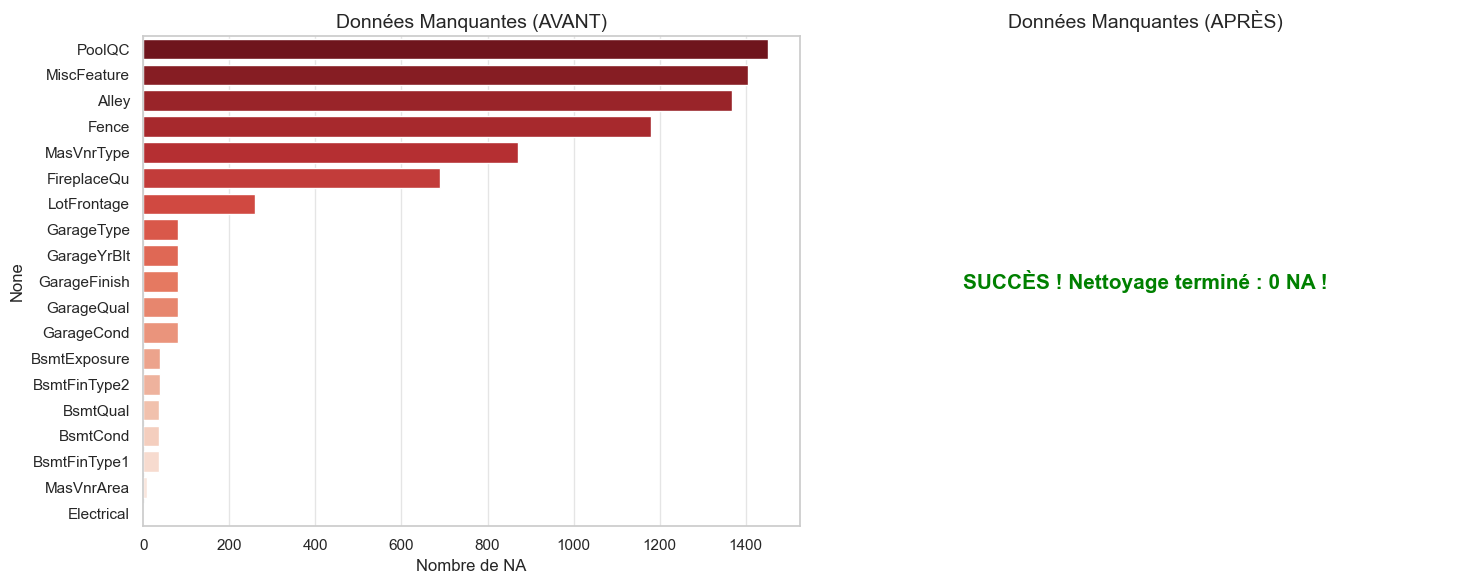

Total NA avant : 7829
Total NA après  : 0


In [55]:
# 1. Chargement des données (Séparateur spécifique ;)
df = pd.read_csv('./data/train.csv', sep=',')

# 2. Définition de la fonction d'imputation "Intelligente"
def intelligent_imputation(df):
    df_imputed = df.copy()

    # NA = "None" (Absence d'équipement)
    none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
                 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
                 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
                 'BsmtFinType2', 'MasVnrType']
    for col in none_cols:
        if col in df_imputed.columns:
            df_imputed[col] = df_imputed[col].fillna('None')

    # NA = 0 (Absence de surface/garage)
    zero_cols = ['GarageYrBlt', 'GarageArea', 'GarageCars', 'BsmtFinSF1',
                 'BsmtFinSF2', 'BsmtUnfSF','TotalBsmtSF', 'BsmtFullBath',
                 'BsmtHalfBath', 'MasVnrArea']
    for col in zero_cols:
        if col in df_imputed.columns:
            df_imputed[col] = df_imputed[col].fillna(0)

    # Imputation par la médiane du quartier (LotFrontage)
    if 'LotFrontage' in df_imputed.columns and 'Neighborhood' in df_imputed.columns:
        df_imputed['LotFrontage'] = df_imputed.groupby('Neighborhood')['LotFrontage'].transform(
            lambda x: x.fillna(x.median())
        )

    # Imputation par le Mode (Valeurs les plus fréquentes)
    mode_cols = ['MSZoning', 'Electrical', 'KitchenQual', 'Exterior1st', 'Exterior2nd', 'SaleType']
    for col in mode_cols:
        if col in df_imputed.columns:
            df_imputed[col] = df_imputed[col].fillna(df_imputed[col].mode()[0])

    # Cas particulier Functional
    if 'Functional' in df_imputed.columns:
        df_imputed['Functional'] = df_imputed['Functional'].fillna('Typ')

    # Suppression Utilities (Trop peu d'information)
    if 'Utilities' in df_imputed.columns:
        df_imputed = df_imputed.drop(['Utilities'], axis=1)

    return df_imputed

# 3. Analyse AVANT Imputation
missing_before = df.isnull().sum()
missing_before = missing_before[missing_before > 0].sort_values(ascending=False)

# 4. Exécution de l'imputation
df_cleaned = intelligent_imputation(df)

# 5. Analyse APRÈS Imputation
missing_after = df_cleaned.isnull().sum()
missing_after = missing_after[missing_after > 0] # On espère que c'est vide !

# 6. Visualisation comparative
plt.figure(figsize=(15, 6))

# Graphique AVANT
plt.subplot(1, 2, 1)
if not missing_before.empty:
    sns.barplot(x=missing_before.values, y=missing_before.index, hue=missing_before.index, palette='Reds_r', legend=False)
    plt.title("Données Manquantes (AVANT)", fontsize=14)
    plt.xlabel("Nombre de NA")
else:
    plt.text(0.5, 0.5, "Aucune donnée manquante", ha='center')

# Graphique APRÈS
plt.subplot(1, 2, 2)
if not missing_after.empty:
    sns.barplot(x=missing_after.values, y=missing_after.index, hue=missing_before.index, palette='Blues_r', legend=False)
    plt.title("Données Manquantes restantes (APRÈS)", fontsize=14)
else:
    # Si tout est propre, on affiche un message de succès
    plt.text(0.5, 0.5, "SUCCÈS ! Nettoyage terminé : 0 NA !",
             ha='center', va='center', fontsize=15, color='green', fontweight='bold')
    plt.title("Données Manquantes (APRÈS)", fontsize=14)
    plt.gca().set_axis_off()

plt.tight_layout()
plt.show()

# Affichage du résumé final
print(f"Total NA avant : {missing_before.sum()}")
print(f"Total NA après  : {df_cleaned.isnull().sum().sum()}")

#### 5. Préparation des données (à affiner)

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

# Encodage ordinal
ord_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
ordinal_cols = [
    'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC',
    'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC'
]

for col in ordinal_cols:
    if col in df_cleaned.columns and df_cleaned[col].dtype == 'object':
        df_cleaned[col] = df_cleaned[col].fillna('None').map(ord_map)

# Encodage one-hot
df_final = pd.get_dummies(df_cleaned, drop_first=False)

# Sécurité
df_final = df_final.fillna(0)

# Variables explicatives et cible
X = df_final.drop(columns=['SalePrice', 'SalePrice_log', 'Id'], errors='ignore')
y_log = np.log1p(df_final['SalePrice'])

# Split
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)

# Modèles
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

rf.fit(X_train, y_train_log)
gb.fit(X_train, y_train_log)

y_pred_rf = rf.predict(X_test)
y_pred_gb = gb.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test_log, y_pred_rf))
rmse_gb = np.sqrt(mean_squared_error(y_test_log, y_pred_gb))

results_rmse = {
    'Random Forest': rmse_rf,
    'Gradient Boosting': rmse_gb
}

results = pd.DataFrame({
    'Model': list(results_rmse.keys()),
    'RMSE_log': list(results_rmse.values())
})

display(results.sort_values(by='RMSE_log'))

X_train : (1168, 300)
X_test  : (292, 300)


,Model,RMSE_log
1,Gradient Boosting,0.135571
0,Random Forest,0.144907


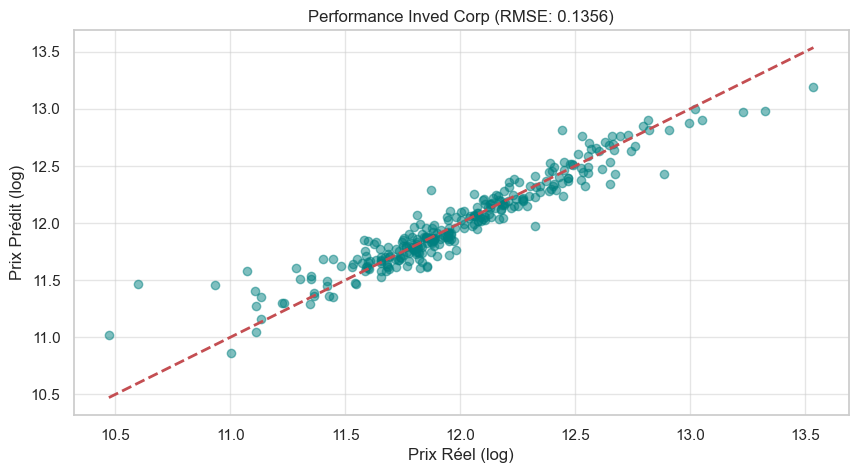

Le score RMSE final du modèle sélectionné est : 0.1356


In [57]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# --- 1. ENCODAGE (Correction de l'erreur 'RL') ---
# Transformation des variables qualitatives en chiffres
df_final = pd.get_dummies(df_cleaned)

# --- 2. PRÉPARATION DES DONNÉES ---
X = df_final.drop(['SalePrice', 'SalePrice_log', 'SalePrice_Log', 'Id'], axis=1, errors='ignore')
y_log = np.log1p(df_final['SalePrice'])

# Séparation Train (80%) / Test (20%)
X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

# --- 3. ENTRAÎNEMENT ---
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

rf.fit(X_train, y_train_log)
gb.fit(X_train, y_train_log)

# --- 4. ÉVALUATION ET GRAPHIQUES ---
y_pred_gb = gb.predict(X_test)
rmse_gb = np.sqrt(mean_squared_error(y_test_log, y_pred_gb))

plt.figure(figsize=(10, 5))
plt.scatter(y_test_log, y_pred_gb, alpha=0.5, color='teal')
plt.plot([y_test_log.min(), y_test_log.max()], [y_test_log.min(), y_test_log.max()], 'r--', lw=2)
plt.title(f"Performance Inved Corp (RMSE: {rmse_gb:.4f})")
plt.xlabel("Prix Réel (log)")
plt.ylabel("Prix Prédit (log)")
plt.show()

print(f"Le score RMSE final du modèle sélectionné est : {rmse_gb:.4f}")

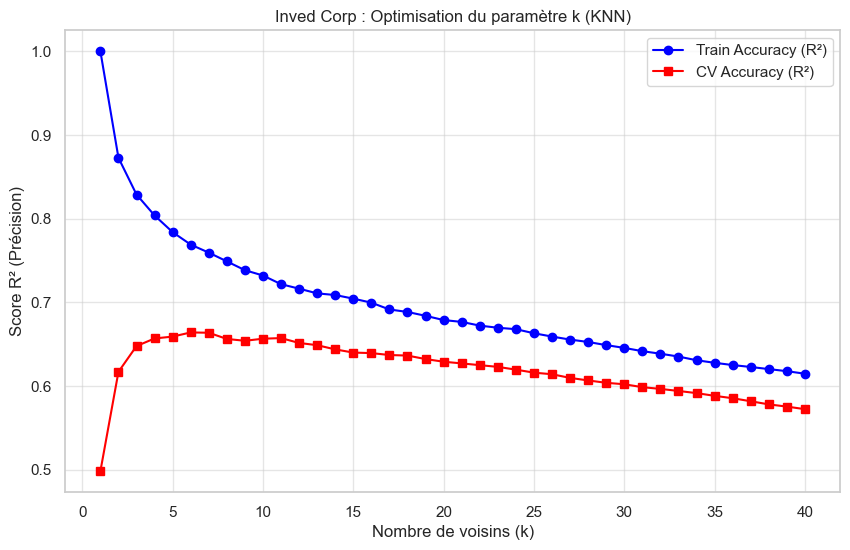

Le meilleur k pour la validation croisée est : 6


In [58]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

# 1. Définir une plage de k (ex: de 1 à 40)
k_range = range(1, 41)
train_scores = []
cv_scores = []

# 2. Boucle pour tester chaque valeur de k
for k in k_range:
    knn = KNeighborsRegressor(n_neighbors=k)

    # Score d'entraînement (sur y_train_log)
    knn.fit(X_train, y_train_log)
    train_scores.append(knn.score(X_train, y_train_log))

    # Score de Validation Croisée (CV) - Moyenne de 5-folds
    scores = cross_val_score(knn, X_train, y_train_log, cv=5)
    cv_scores.append(scores.mean())

# 3. Visualisation des "Accuracies" (R² Score)
plt.figure(figsize=(10, 6))
plt.plot(k_range, train_scores, label='Train Accuracy (R²)', color='blue', marker='o')
plt.plot(k_range, cv_scores, label='CV Accuracy (R²)', color='red', marker='s')

plt.title('Inved Corp : Optimisation du paramètre k (KNN)')
plt.xlabel('Nombre de voisins (k)')
plt.ylabel('Score R² (Précision)')
plt.legend()
plt.grid(True)
plt.show()

# Identifier le meilleur k
best_k = k_range[np.argmax(cv_scores)]
print(f"Le meilleur k pour la validation croisée est : {best_k}")

Début de l'évaluation des modèles pour InVed Corp...
SUCCÈS ! Random Forest terminé. RMSE : 0.1449
SUCCÈS ! AdaBoost terminé. RMSE : 0.1808
SUCCÈS ! XGBoost terminé. RMSE : 0.1440
SUCCÈS ! Stacking terminé. RMSE : 0.1340


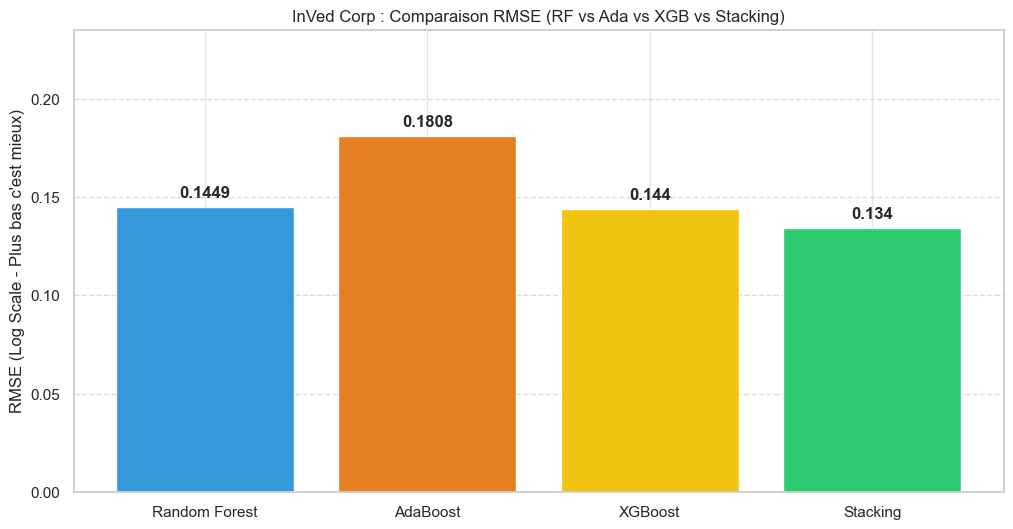

In [59]:
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, StackingRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor # Ajout de XGBoost
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Définition des modèles ---

# Modèle 1 : Random Forest (Baseline)
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)

# Modèle 2 : AdaBoost
ada = AdaBoostRegressor(n_estimators=100, random_state=42)

# Modèle 3 : XGBoost (Le nouveau challenger performant)
xgb = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42)

# Modèle 4 : Stacking (L'ensemble combiné)
# On peut aussi ajouter XGBoost à l'intérieur du stacking pour encore plus de puissance
estimators = [
    ('rf', RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42)),
    ('gbr', GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)),
    ('xgb', XGBRegressor(n_estimators=50, learning_rate=0.1, max_depth=3, random_state=42))
]
stack = StackingRegressor(estimators=estimators, final_estimator=RidgeCV())

# --- 2. Entraînement et Évaluation ---

# Ajout de XGBoost au dictionnaire
models = {
    'Random Forest': rf,
    'AdaBoost': ada,
    'XGBoost': xgb,
    'Stacking': stack
}
results_rmse = {}

print("Début de l'évaluation des modèles pour InVed Corp...")
for name, model in models.items():
    model.fit(X_train, y_train_log)
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test_log, preds))
    results_rmse[name] = rmse
    print(f"SUCCÈS ! {name} terminé. RMSE : {rmse:.4f}")

# --- 3. Visualisation de la performance ---

plt.figure(figsize=(12, 6))
# Mise à jour des couleurs pour inclure le 4ème modèle
colors = ['#3498db', '#e67e22', '#f1c40f', '#2ecc71']
bars = plt.bar(results_rmse.keys(), results_rmse.values(), color=colors)
plt.title('InVed Corp : Comparaison RMSE (RF vs Ada vs XGB vs Stacking)')
plt.ylabel('RMSE (Log Scale - Plus bas c\'est mieux)')
plt.ylim(0, max(results_rmse.values()) * 1.3)

# Ajout des étiquettes de score sur les barres
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, round(yval, 4),
             ha='center', fontweight='bold', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


--- Évaluation des modèles de régularisation linéaire ---
SUCCÈS ! Lasso terminé. RMSE : 0.1292
SUCCÈS ! Ridge terminé. RMSE : 0.1262
SUCCÈS ! ElasticNet terminé. RMSE : 0.1298


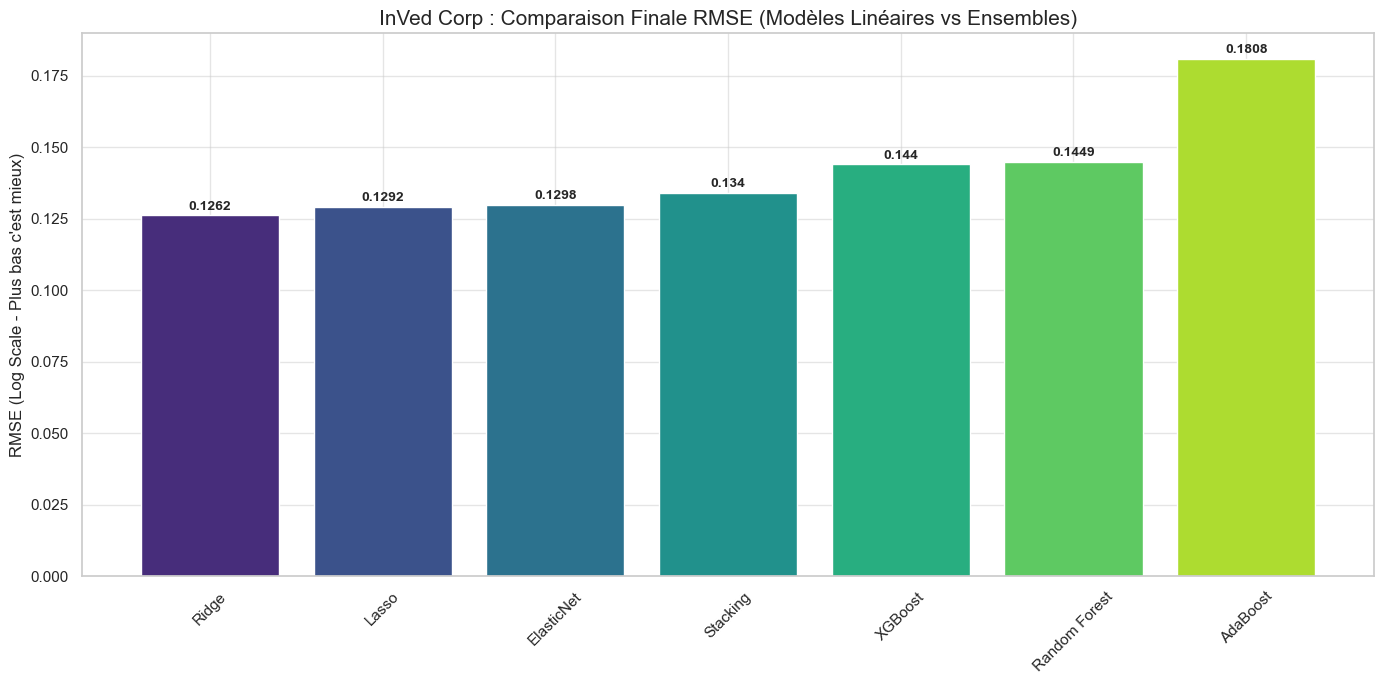


--- Analyse de Robustesse (Lasso) ---
Variables totales : 300
Variables ignorées (Coef = 0) : 235
Variables conservées : 65

Top 10 des variables les plus déterminantes pour le prix :
              Feature  Importance
15          GrLivArea    0.127689
3         OverallQual    0.089876
123  RoofMatl_ClyTile    0.064167
5           YearBuilt    0.042050
11        TotalBsmtSF    0.035502
4         OverallCond    0.030464
100   Condition2_PosN    0.026211
25         GarageCars    0.024870
6        YearRemodAdd    0.023934
26         GarageArea    0.022241


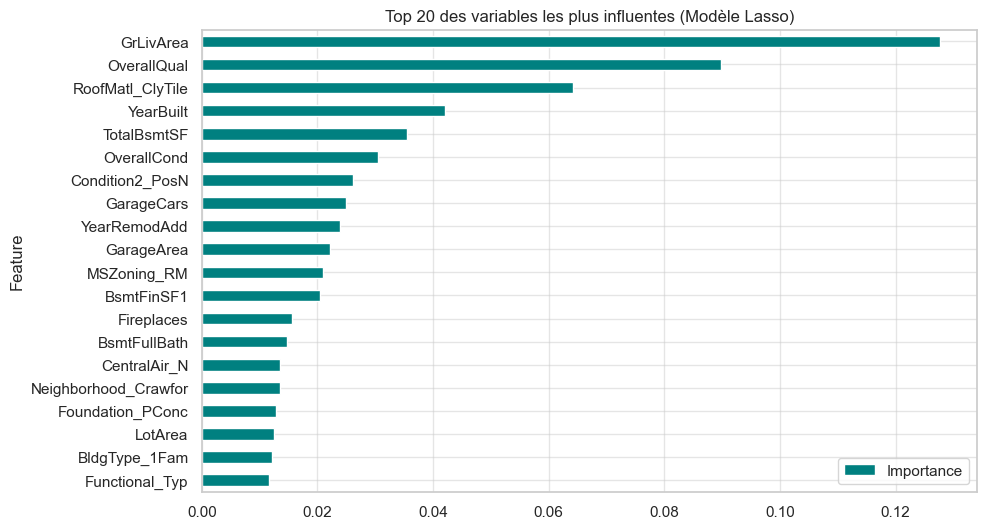

In [60]:
from sklearn.linear_model import LassoCV, RidgeCV, ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Définition des modèles avec Pipeline (Scaling + Modèle) ---
# Le scaling est CRUCIAL pour Lasso/Ridge. max_iter est augmenté pour éviter les warnings de convergence.

lasso_pipe = make_pipeline(StandardScaler(), LassoCV(alphas=np.logspace(-4, 2, 20), cv=5, max_iter=50000, random_state=42))
ridge_pipe = make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-2, 2, 20), cv=5))
elastic_pipe = make_pipeline(StandardScaler(), ElasticNetCV(l1_ratio=[.1, .5, .7, .9, .95, .99, 1],
                                                           alphas=np.logspace(-4, 2, 20), cv=5, max_iter=50000, random_state=42))

# --- 2. Mise à jour du dictionnaire de modèles ---
# On ajoute ces nouveaux modèles à ceux que tu as déjà (RF, XGB, etc.)
new_models = {
    'Lasso': lasso_pipe,
    'Ridge': ridge_pipe,
    'ElasticNet': elastic_pipe
}

# Si tu veux fusionner avec tes anciens modèles pour le graphique final :
# models.update(new_models)

print("\n--- Évaluation des modèles de régularisation linéaire ---")

for name, model in new_models.items():
    model.fit(X_train, y_train_log)
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test_log, preds))
    results_rmse[name] = rmse  # On stocke dans ton dictionnaire de résultats global
    print(f"SUCCÈS ! {name} terminé. RMSE : {rmse:.4f}")

# --- 3. Visualisation comparative mise à jour ---
plt.figure(figsize=(14, 7))
# On trie les résultats du meilleur (plus bas RMSE) au moins bon
sorted_results = dict(sorted(results_rmse.items(), key=lambda item: item[1]))

colors = sns.color_palette("viridis", len(sorted_results))
bars = plt.bar(sorted_results.keys(), sorted_results.values(), color=colors)

plt.title('InVed Corp : Comparaison Finale RMSE (Modèles Linéaires vs Ensembles)', fontsize=15)
plt.ylabel('RMSE (Log Scale - Plus bas c\'est mieux)')
plt.xticks(rotation=45)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.002, round(yval, 4),
             ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

# --- 4. BONUS : Analyse des variables sélectionnées par le Lasso ---

# Pour accéder aux coefficients, on doit "entrer" dans le pipeline via 'lassocv'
lasso_final = lasso_pipe.named_steps['lassocv']
n_zero = np.sum(lasso_final.coef_ == 0)
n_total = len(lasso_final.coef_)

print(f"\n--- Analyse de Robustesse (Lasso) ---")
print(f"Variables totales : {n_total}")
print(f"Variables ignorées (Coef = 0) : {n_zero}")
print(f"Variables conservées : {n_total - n_zero}")

# Top 10 des variables les plus importantes
coef_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': np.abs(lasso_final.coef_)
}).sort_values(by='Importance', ascending=False)

print("\nTop 10 des variables les plus déterminantes pour le prix :")
print(coef_importance.head(10))

# Visualisation des coefficients
plt.figure(figsize=(10, 6))
coef_importance.head(20).plot(kind='barh', x='Feature', y='Importance', color='teal', ax=plt.gca())
plt.title("Top 20 des variables les plus influentes (Modèle Lasso)")
plt.gca().invert_yaxis()
plt.show()